# Indic script routing research notebook

This notebook implements the five-part plan:
1. Split hypotheses into clean prompt conditions.
2. Run a benchmark-style baseline on a toy dataset.
3. Build controlled logit-lens routing curves and select candidate layers.
4. Run two-pass activation patching.
5. Compute and test a simple steering vector.

The notebook is designed to run on **Google Colab** or **Kaggle** with a small decoder-only model.
The default model is **Qwen/Qwen2.5-0.5B-Instruct** because it is easy to access and small enough for a free GPU.

## Cell 1 — Install packages

What this cell does:
- Installs the minimal packages needed for model loading, plotting, and tabular analysis.
- `bitsandbytes` is optional and only needed if you set `USE_4BIT=True` later.

Expected output:
- Standard pip installation logs.
- No tables or plots yet.

In [15]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers", "accelerate", "sentencepiece", "pandas", "numpy", "matplotlib", "tqdm"])

0

## Cell 2 — Imports and configuration

What this cell does:
- Imports all libraries.
- Sets the runtime configuration.
- Keeps the default run small enough for free Colab/Kaggle GPUs.

Expected output:
- A small config summary showing the selected model, device, and sample size.

In [16]:
import math
import os
import pickle
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# -----------------------------
# Runtime configuration
# -----------------------------
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
# Safer default for free Colab/Kaggle. If you switch to Gemma 2B and hit OOM,
# set USE_4BIT=True and install bitsandbytes in Cell 1.
USE_4BIT = False

MAX_NEW_TOKENS = 24
TEMPERATURE = 0.0  # greedy decoding
WORKING_SAMPLE_SIZE = 4  # set to None to use the full toy dataset
FOCUS_LAST_N = 10

PROMPT_CONDITIONS = [
    "direct",
    "english_pivot",
    "roman_pivot",
    "deva_script_pivot",
    "hindi_pivot",
]

SCRIPT_VARIANTS = [
    "native",
    "romanized",
    "devanagari_mapped",
]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32
CACHE_DIR = Path("./cache_indic_routing")
CACHE_DIR.mkdir(exist_ok=True)

print({
    "MODEL_NAME": MODEL_NAME,
    "USE_4BIT": USE_4BIT,
    "DEVICE": str(DEVICE),
    "WORKING_SAMPLE_SIZE": WORKING_SAMPLE_SIZE,
    "MAX_NEW_TOKENS": MAX_NEW_TOKENS,
    "FOCUS_LAST_N": FOCUS_LAST_N,
})

{'MODEL_NAME': 'Qwen/Qwen2.5-0.5B-Instruct', 'USE_4BIT': False, 'DEVICE': 'cuda', 'WORKING_SAMPLE_SIZE': 4, 'MAX_NEW_TOKENS': 24, 'FOCUS_LAST_N': 10}


## Cell 3 — Runtime advice

What this cell does:
- Prints a practical recommendation for which model size to use first.
- This is only advisory; it does not load a model yet.

Expected output:
- A text recommendation. For a free GPU, you should see advice to start with Qwen 0.5B.

In [17]:
def runtime_advice(model_name: str, use_4bit: bool, device: torch.device) -> None:
    print("Runtime advice")
    print("- Start with Qwen/Qwen2.5-0.5B-Instruct for the first end-to-end run.")
    print("- Move to Gemma 2B only after the pipeline is stable.")
    print("- Logit lens itself is not the expensive part; repeated generation, patch sweeps, and full-dataset runs are.")
    if device.type == "cuda":
        print("- GPU detected. You can run the toy pipeline end-to-end.")
        if use_4bit:
            print("- 4-bit loading is enabled. This is useful for Gemma 2B or larger models.")
        else:
            print("- 4-bit loading is disabled. This is fine for Qwen 0.5B on a typical free GPU.")
    else:
        print("- No GPU detected. The notebook can still run, but generation, logit lens, and patching will be slow.")

runtime_advice(MODEL_NAME, USE_4BIT, DEVICE)

Runtime advice
- Start with Qwen/Qwen2.5-0.5B-Instruct for the first end-to-end run.
- Move to Gemma 2B only after the pipeline is stable.
- Logit lens itself is not the expensive part; repeated generation, patch sweeps, and full-dataset runs are.
- GPU detected. You can run the toy pipeline end-to-end.
- 4-bit loading is disabled. This is fine for Qwen 0.5B on a typical free GPU.


## Cell 4 — Build a custom toy dataset

What this cell does:
- Creates a fully self-contained toy dataset with aligned fields for:
  - native source
  - romanized source
  - Devanagari-mapped source
  - English gloss
  - Hindi pivot
  - target reference
- Includes two pairs:
  - Gujarati → Marathi (control where the target uses Devanagari)
  - Gujarati → Bengali (stress test where neither side uses Devanagari)

Expected output:
- A dataframe preview.
- You should see one row per example with all pivot fields already prepared.

In [36]:
import pandas as pd

# Set this to a number to limit the rows, or None to use the full dataset
WORKING_SAMPLE_SIZE = None 

# -----------------------------
# Unique Word-to-Word Toy Dataset
# -----------------------------

rows = [

    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w1",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "पाणी",
        "source_roman": "paani",
        "source_devanagari": "पाणी",
        "pivot_english": "Water",
        "pivot_hindi": "पानी",
        "target_reference": "પાણી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w2",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "सूर्य",
        "source_roman": "soorya",
        "source_devanagari": "सूर्य",
        "pivot_english": "Sun",
        "pivot_hindi": "सूर्य",
        "target_reference": "સૂર્ય"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w3",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "चंद्र",
        "source_roman": "chandra",
        "source_devanagari": "चंद्र",
        "pivot_english": "Moon",
        "pivot_hindi": "चंद्र",
        "target_reference": "ચંદ્ર"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w4",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "आकाश",
        "source_roman": "aakaash",
        "source_devanagari": "आकाश",
        "pivot_english": "Sky",
        "pivot_hindi": "आकाश",
        "target_reference": "આકાશ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w5",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "आग",
        "source_roman": "aag",
        "source_devanagari": "आग",
        "pivot_english": "Fire",
        "pivot_hindi": "आग",
        "target_reference": "આગ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w6",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "वारा",
        "source_roman": "vaara",
        "source_devanagari": "वारा",
        "pivot_english": "Wind",
        "pivot_hindi": "हवा",
        "target_reference": "પવન"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w7",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "झाड",
        "source_roman": "zhaad",
        "source_devanagari": "झाड",
        "pivot_english": "Tree",
        "pivot_hindi": "पेड़",
        "target_reference": "ઝાડ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w8",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "फूल",
        "source_roman": "phool",
        "source_devanagari": "फूल",
        "pivot_english": "Flower",
        "pivot_hindi": "फूल",
        "target_reference": "ફૂલ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w9",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "फळ",
        "source_roman": "phal",
        "source_devanagari": "फळ",
        "pivot_english": "Fruit",
        "pivot_hindi": "फल",
        "target_reference": "ફળ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w10",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "प्राणी",
        "source_roman": "praani",
        "source_devanagari": "प्राणी",
        "pivot_english": "Animal",
        "pivot_hindi": "प्राणी",
        "target_reference": "પ્રાણી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w11",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "पक्षी",
        "source_roman": "pakshi",
        "source_devanagari": "पक्षी",
        "pivot_english": "Bird",
        "pivot_hindi": "पक्षी",
        "target_reference": "પક્ષી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w12",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "मासा",
        "source_roman": "maasa",
        "source_devanagari": "मासा",
        "pivot_english": "Fish",
        "pivot_hindi": "मछली",
        "target_reference": "માછલી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w13",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "घर",
        "source_roman": "ghar",
        "source_devanagari": "घर",
        "pivot_english": "House",
        "pivot_hindi": "घर",
        "target_reference": "ઘર"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w14",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "दरवाजा",
        "source_roman": "darvaaja",
        "source_devanagari": "दरवाजा",
        "pivot_english": "Door",
        "pivot_hindi": "दरवाज़ा",
        "target_reference": "દરવાજો"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w15",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "पुस्तक",
        "source_roman": "pustak",
        "source_devanagari": "पुस्तक",
        "pivot_english": "Book",
        "pivot_hindi": "पुस्तक",
        "target_reference": "પુસ્તક"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w16",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "दिवस",
        "source_roman": "divas",
        "source_devanagari": "दिवस",
        "pivot_english": "Day",
        "pivot_hindi": "दिन",
        "target_reference": "દિવસ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w17",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "रात्र",
        "source_roman": "raatra",
        "source_devanagari": "रात्र",
        "pivot_english": "Night",
        "pivot_hindi": "रात",
        "target_reference": "રાત"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w18",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "नाव",
        "source_roman": "naav",
        "source_devanagari": "नाव",
        "pivot_english": "Name",
        "pivot_hindi": "नाम",
        "target_reference": "નામ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w19",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "दूध",
        "source_roman": "doodh",
        "source_devanagari": "दूध",
        "pivot_english": "Milk",
        "pivot_hindi": "दूध",
        "target_reference": "દૂધ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w20",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "रंग",
        "source_roman": "rang",
        "source_devanagari": "रंग",
        "pivot_english": "Color",
        "pivot_hindi": "रंग",
        "target_reference": "રંગ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w21",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "डोळा",
        "source_roman": "dola",
        "source_devanagari": "डोळा",
        "pivot_english": "Eye",
        "pivot_hindi": "आँख",
        "target_reference": "આંખ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w22",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "हात",
        "source_roman": "haat",
        "source_devanagari": "हात",
        "pivot_english": "Hand",
        "pivot_hindi": "हाथ",
        "target_reference": "હાથ"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w23",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "पृथ्वी",
        "source_roman": "prithvi",
        "source_devanagari": "पृथ्वी",
        "pivot_english": "Earth",
        "pivot_hindi": "पृथ्वी",
        "target_reference": "પૃથ્વી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w24",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "रक्त",
        "source_roman": "rakta",
        "source_devanagari": "रक्त",
        "pivot_english": "Blood",
        "pivot_hindi": "रक्त",
        "target_reference": "લોહી"
    },
    {
        "pair": "mr_to_gu",
        "example_id": "mr_gu_w25",
        "source_lang": "Marathi",
        "target_lang": "Gujarati",
        "target_script": "gujarati",
        "source_native": "सोने",
        "source_roman": "sone",
        "source_devanagari": "सोने",
        "pivot_english": "Gold",
        "pivot_hindi": "सोना",
        "target_reference": "સોનું"
    }
]


toy_df = pd.DataFrame(rows)

# Subsetting logic
if WORKING_SAMPLE_SIZE is not None:
    work_df = toy_df.head(WORKING_SAMPLE_SIZE).copy()
else:
    work_df = toy_df.copy()

print(f"Toy dataset rows: {len(toy_df)} | Working subset rows: {len(work_df)}")
# In Jupyter use: display(work_df)
print(work_df[['pair', 'pivot_english', 'source_native', 'target_reference']])

Toy dataset rows: 25 | Working subset rows: 25
        pair pivot_english source_native target_reference
0   mr_to_gu         Water          पाणी             પાણી
1   mr_to_gu           Sun         सूर्य            સૂર્ય
2   mr_to_gu          Moon         चंद्र            ચંદ્ર
3   mr_to_gu           Sky          आकाश             આકાશ
4   mr_to_gu          Fire            आग               આગ
5   mr_to_gu          Wind          वारा              પવન
6   mr_to_gu          Tree           झाड              ઝાડ
7   mr_to_gu        Flower           फूल              ફૂલ
8   mr_to_gu         Fruit            फळ               ફળ
9   mr_to_gu        Animal        प्राणी           પ્રાણી
10  mr_to_gu          Bird         पक्षी            પક્ષી
11  mr_to_gu          Fish          मासा            માછલી
12  mr_to_gu         House            घर               ઘર
13  mr_to_gu          Door        दरवाजा           દરવાજો
14  mr_to_gu          Book        पुस्तक           પુસ્તક
15  mr_to_gu           Da

## Cell 5 — Cleanly split the prompt conditions

What this cell does:
- Implements the clean condition split that the research plan needs:
  - direct
  - English pivot
  - Romanized pivot
  - Devanagari script pivot
  - Hindi pivot
- Also creates a separate family of **script-variant prompts** for pass-A patching.

Expected output:
- You should see one example prompt for every condition.
- This is where you verify that Devanagari-script mapping and Hindi pivot are kept separate.

In [79]:
baseline_rows = []
all_trace_rows = []
all_token_rows = []

# Use enumerate to get the index (idx) needed for the few-shot builder
for idx, (row_idx, row) in tqdm(enumerate(work_df.iterrows()), total=len(work_df), desc="Evaluating Conditions"):
    for condition in PROMPT_CONDITIONS:
        
        # 1. BUILD THE FEW-SHOT PROMPT
        # This uses the previous 5 rows as examples for the current row
        full_prompt_text = build_romanlens_few_shot_prompt(
            df=work_df, 
            target_index=idx, 
            condition=condition, 
            num_shots=5
        )
        
        # 2. ENCODE THE PROMPT
        # We use a simple encode here because the few-shot builder already 
        # created the full string including the open quote.
        input_ids = tokenizer.encode(full_prompt_text, return_tensors="pt").to(DEVICE)

        # 3. GENERATE WITH TRACES
        # greedy_generate_with_traces will start generating right after the open quote
        pred_text, trace_df, token_df, _ = greedy_generate_with_traces(model, tokenizer, input_ids)

        # 4. POST-PROCESS PREDICTION
        # If the model generates a closing quote or extra lines, clean it up
        clean_pred = pred_text.split('"')[0].split('\n')[0].strip()

        # 5. LOGGING & METRICS
        trace_df["example_id"] = row["example_id"]
        trace_df["pair"] = row["pair"]
        trace_df["condition"] = condition
        trace_df["target_script"] = row["target_script"]

        token_df["example_id"] = row["example_id"]
        token_df["pair"] = row["pair"]
        token_df["condition"] = condition

        all_trace_rows.append(trace_df)
        all_token_rows.append(token_df)

        baseline_rows.append({
            "pair": row["pair"],
            "example_id": row["example_id"],
            "condition": condition,
            "target_script": row["target_script"],
            "reference": row["target_reference"],
            "prediction": clean_pred,
            "exact_match": int(normalize_text(clean_pred) == normalize_text(row["target_reference"])),
            "char_f1": char_f1(clean_pred, row["target_reference"]),
            "target_script_ratio": target_script_ratio(clean_pred, row["target_script"]),
        })

# Create final DataFrame
baseline_df = pd.DataFrame(baseline_rows)
traces_df = pd.concat(all_trace_rows, ignore_index=True) if all_trace_rows else pd.DataFrame()
tokens_df = pd.concat(all_token_rows, ignore_index=True) if all_token_rows else pd.DataFrame()

# Quick look at the new results
print(f"Evaluation complete. Results for {len(baseline_df)} scenarios.")
display(baseline_df.groupby(["pair", "condition"])[["exact_match", "char_f1", "target_script_ratio"]].mean())

Evaluating Conditions: 100%|██████████| 25/25 [03:48<00:00,  9.15s/it]

Evaluation complete. Results for 125 scenarios.


exact_match   char_f1  target_script_ratio
pair     condition                                                    
mr_to_gu deva_script_pivot         0.20  0.491532             0.736667
         direct                    0.08  0.398476             0.680000
         english_pivot             0.04  0.258329             1.000000
         hindi_pivot               0.24  0.527405             0.845333
         roman_pivot               0.04  0.504567             0.960000

## Cell 6 — Load model and tokenizer

What this cell does:
- Loads the small causal LM and tokenizer.
- Keeps the default path simple and stable for Colab/Kaggle.
- Uses plain fp16 on GPU by default, which is enough for Qwen 0.5B.

Expected output:
- A short model summary with the number of layers and hidden size.
- If you switch to Gemma 2B and get out-of-memory errors, this is where you turn on `USE_4BIT=True`.

In [27]:
if USE_4BIT:
    from transformers import BitsAndBytesConfig


def load_model_and_tokenizer(model_name: str, use_4bit: bool = False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if use_4bit:
        if DEVICE.type != "cuda":
            raise RuntimeError("USE_4BIT=True requires a GPU runtime.")
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=quant_config,
            device_map="auto",
            trust_remote_code=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=DTYPE,
            trust_remote_code=True,
        )
        model.to(DEVICE)

    model.eval()
    return tokenizer, model


tokenizer, model = load_model_and_tokenizer(MODEL_NAME, use_4bit=USE_4BIT)
base_model = model.model if hasattr(model, "model") else model
n_layers = getattr(model.config, "num_hidden_layers", None)
hidden_size = getattr(model.config, "hidden_size", None)

print({
    "loaded_model": MODEL_NAME,
    "num_hidden_layers": n_layers,
    "hidden_size": hidden_size,
    "tokenizer_vocab_size": len(tokenizer),
})

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

{'loaded_model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_hidden_layers': 24, 'hidden_size': 896, 'tokenizer_vocab_size': 151665}


## Cell 7 — Helper functions for exact source spans and simple evaluation

What this cell does:
- Encodes prompt segments separately, so source token spans are known exactly.
- Defines simple evaluation metrics that work on the toy dataset.
- For the toy run, `char_f1` and `target_script_ratio` are more stable than exact match.

Expected output:
- A short encoded-prompt sanity check.
- You should see the source token span indices for one example.

In [65]:
def encode_segments(tokenizer, segments, device=DEVICE):
    prefix, source_text, suffix = segments
    bos_ids = [tokenizer.bos_token_id] if tokenizer.bos_token_id is not None else []
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    source_ids = tokenizer.encode(source_text, add_special_tokens=False)
    suffix_ids = tokenizer.encode(suffix, add_special_tokens=False)

    input_ids = bos_ids + prefix_ids + source_ids + suffix_ids
    source_start = len(bos_ids) + len(prefix_ids)
    source_end = source_start + len(source_ids) - 1

    encoded = torch.tensor([input_ids], dtype=torch.long, device=device)
    meta = {
        "source_start": source_start,
        "source_end": source_end,
        "prefix_len": len(prefix_ids),
        "source_len": len(source_ids),
        "suffix_len": len(suffix_ids),
        "prompt_text": prefix + source_text + suffix,
        "source_text": source_text,
    }
    return encoded, meta


def normalize_text(text: str) -> str:
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


def char_f1(pred: str, ref: str) -> float:
    pred = normalize_text(pred)
    ref = normalize_text(ref)
    pred_counter = Counter(pred)
    ref_counter = Counter(ref)
    overlap = sum((pred_counter & ref_counter).values())
    precision = overlap / max(1, len(pred))
    recall = overlap / max(1, len(ref))
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


SCRIPT_RANGES = {
    "latin": [(0x0041, 0x024F), (0x1E00, 0x1EFF)],
    "devanagari": [(0x0900, 0x097F), (0xA8E0, 0xA8FF)],
    "bengali": [(0x0980, 0x09FF)],
    "gujarati": [(0x0A80, 0x0AFF)],
}


def char_script(char: str):
    cp = ord(char)
    for script, ranges in SCRIPT_RANGES.items():
        for lo, hi in ranges:
            if lo <= cp <= hi:
                return script
    return None


def target_script_ratio(text: str, target_script: str) -> float:
    counted = 0
    target = 0
    for ch in text:
        s = char_script(ch)
        if s is not None:
            counted += 1
            if s == target_script:
                target += 1
    if counted == 0:
        return 0.0
    return target / counted


sample_segments = prompt_segments_from_condition(work_df.iloc[0], "direct")
sample_input_ids, sample_meta = encode_segments(tokenizer, sample_segments)
print({
    "input_shape": tuple(sample_input_ids.shape),
    "source_start": sample_meta["source_start"],
    "source_end": sample_meta["source_end"],
    "source_text": sample_meta["source_text"],
})

{'input_shape': (1, 14), 'source_start': 4, 'source_end': 7, 'source_text': 'पाणी'}


In [72]:
import unicodedata
from collections import Counter, defaultdict
import pickle
from tqdm import tqdm
import torch

# ---------------------------------------------------------
# 1. Improved Script Detection for Marathi & Gujarati
# ---------------------------------------------------------
def char_script(ch: str) -> str:
    """
    Identifies if a character belongs to Latin, Devanagari (Marathi), 
    or Gujarati scripts using Unicode names.
    """
    try:
        name = unicodedata.name(ch).upper()
        if "DEVANAGARI" in name:
            return "devanagari"
        if "GUJARATI" in name:
            return "gujarati"
        if "LATIN" in name:
            return "latin"
        return "other"
    except ValueError:
        return "other"

def dominant_script_for_token_text(token_text: str) -> str:
    # Remove common tokenizer artifacts (byte-level markers)
    cleaned = token_text.replace("▁", "").replace("Ġ", "").replace(" ", "").strip()
    if not cleaned:
        return "other"
        
    counts = Counter()
    for ch in cleaned:
        s = char_script(ch)
        counts[s] += 1
    
    if not counts:
        return "other"
    
    # If a token contains multiple scripts (e.g., "म_word"), mark as mixed
    if len([k for k, v in counts.items() if v > 0]) > 1:
        return "mixed"
        
    return counts.most_common(1)[0][0]

# ---------------------------------------------------------
# 2. Vocabulary Cache Logic
# ---------------------------------------------------------
def build_or_load_vocab_script_cache(tokenizer, model_name: str):
    safe_name = model_name.replace("/", "__")
    cache_path = CACHE_DIR / f"vocab_script_map__{safe_name}.pkl"

    if cache_path.exists():
        print(f"Loading script cache from {cache_path}")
        with open(cache_path, "rb") as f:
            data = pickle.load(f)
    else:
        vocab_size = len(tokenizer)
        id_to_bucket = {}
        bucket_to_ids = defaultdict(list)
        
        for token_id in tqdm(range(vocab_size), desc="Mapping Vocab to Scripts"):
            token_text = tokenizer.decode([token_id], skip_special_tokens=False)
            bucket = dominant_script_for_token_text(token_text)
            id_to_bucket[token_id] = bucket
            bucket_to_ids[bucket].append(token_id)
            
        data = {
            "id_to_bucket": id_to_bucket,
            "bucket_to_ids": dict(bucket_to_ids),
        }
        with open(cache_path, "wb") as f:
            pickle.dump(data, f)

    return data

# ---------------------------------------------------------
# 3. Mask Generation (Marathi-Gujarati focused)
# ---------------------------------------------------------
vocab_script_cache = build_or_load_vocab_script_cache(tokenizer, MODEL_NAME)
bucket_to_ids = vocab_script_cache["bucket_to_ids"]

# Dimension of the model's output head
logit_dim = model.lm_head.out_features

# We removed 'bengali' and kept scripts relevant to Marathi (Devanagari) and Gujarati
SCRIPT_BUCKETS = ["latin", "devanagari", "gujarati", "mixed", "other"]

SCRIPT_MASKS = {}
for bucket in SCRIPT_BUCKETS:
    mask = torch.zeros(logit_dim, dtype=torch.bool, device=DEVICE)
    ids = bucket_to_ids.get(bucket, [])
    if ids:
        # Filter IDs that exist within the model's logit dimension
        valid_ids = [i for i in ids if i < logit_dim]
        mask[torch.tensor(valid_ids, dtype=torch.long, device=DEVICE)] = True
    SCRIPT_MASKS[bucket] = mask

# Print summary to verify token distribution
summary = {bucket: int(SCRIPT_MASKS[bucket].sum().item()) for bucket in SCRIPT_BUCKETS}
print(f"\nMasks aligned to logit dim: {logit_dim}")
print(f"Token counts per script: {summary}")

Loading script cache from cache_indic_routing/vocab_script_map__Qwen__Qwen2.5-0.5B-Instruct.pkl

Masks aligned to logit dim: 151936
Token counts per script: {'latin': 96708, 'devanagari': 71, 'gujarati': 16, 'mixed': 0, 'other': 54823}


## Cell 8 — Build a vocabulary-to-script map for logit lens

What this cell does:
- Decodes every vocabulary item once.
- Assigns each token to a script bucket: Latin, Devanagari, Bengali, Gujarati, mixed, or other.
- Caches the result so you do not need to rebuild it every run.

Expected output:
- A token-count summary by script bucket.
- The counts are usually very uneven because the model vocabulary is not balanced across scripts.

In [73]:
import unicodedata
from collections import Counter, defaultdict
import pickle
from tqdm import tqdm
import torch

# ---------------------------------------------------------
# 1. Helper to identify the script of a character
# ---------------------------------------------------------
def char_script(ch: str) -> str:
    """
    Returns the script name for a character. 
    Marathi uses Devanagari.
    """
    try:
        name = unicodedata.name(ch).upper()
        if "DEVANAGARI" in name:
            return "devanagari"
        if "GUJARATI" in name:
            return "gujarati"
        if "LATIN" in name:
            return "latin"
    except ValueError:
        return None
    return None

def dominant_script_for_token_text(token_text: str) -> str:
    # Remove common tokenizer artifacts (Gemma/Llama/GPT style)
    cleaned = token_text.replace("▁", "").replace("Ġ", "").replace(" ", "").strip()
    
    if not cleaned:
        return "other"
        
    counts = Counter()
    for ch in cleaned:
        s = char_script(ch)
        if s:
            counts[s] += 1
            
    if not counts:
        return "other"
    
    # If a token contains multiple scripts (e.g. "marathi_મ"), label as mixed
    if len(counts) > 1:
        return "mixed"
        
    return counts.most_common(1)[0][0]

# ---------------------------------------------------------
# 2. Cache logic
# ---------------------------------------------------------
def build_or_load_vocab_script_cache(tokenizer, model_name: str):
    safe_name = model_name.replace("/", "__")
    cache_path = CACHE_DIR / f"vocab_script_map__{safe_name}.pkl"

    if cache_path.exists():
        print(f"Loading script cache from {cache_path}")
        with open(cache_path, "rb") as f:
            data = pickle.load(f)
    else:
        vocab_size = len(tokenizer)
        id_to_bucket = {}
        bucket_to_ids = defaultdict(list)
        for token_id in tqdm(range(vocab_size), desc="Building vocab script map"):
            token_text = tokenizer.decode([token_id], skip_special_tokens=False)
            bucket = dominant_script_for_token_text(token_text)
            id_to_bucket[token_id] = bucket
            bucket_to_ids[bucket].append(token_id)
        data = {
            "id_to_bucket": id_to_bucket,
            "bucket_to_ids": dict(bucket_to_ids),
        }
        with open(cache_path, "wb") as f:
            pickle.dump(data, f)

    return data

# ---------------------------------------------------------
# 3. Mask Generation (Marathi-Gujarati focused)
# ---------------------------------------------------------
vocab_script_cache = build_or_load_vocab_script_cache(tokenizer, MODEL_NAME)
bucket_to_ids = vocab_script_cache["bucket_to_ids"]

# Use model logit dimension (crucial for models like Llama-3/Gemma)
logit_dim = model.lm_head.out_features

# Removed 'bengali', kept scripts relevant to Marathi (Devanagari) and Gujarati
SCRIPT_BUCKETS = ["latin", "devanagari", "gujarati", "mixed", "other"]

SCRIPT_MASKS = {}
for bucket in SCRIPT_BUCKETS:
    mask = torch.zeros(logit_dim, dtype=torch.bool, device=DEVICE)
    ids = bucket_to_ids.get(bucket, [])
    if ids:
        # Only include IDs that fall within the model's output layer dimension
        valid_ids = [i for i in ids if i < logit_dim]
        mask[torch.tensor(valid_ids, dtype=torch.long, device=DEVICE)] = True
    SCRIPT_MASKS[bucket] = mask

# Verify the token distribution
summary = {bucket: int(SCRIPT_MASKS[bucket].sum().item()) for bucket in SCRIPT_BUCKETS}
print(f"Masks aligned to logit dim: {logit_dim}")
print(f"Token counts per script: {summary}")

Loading script cache from cache_indic_routing/vocab_script_map__Qwen__Qwen2.5-0.5B-Instruct.pkl
Masks aligned to logit dim: 151936
Token counts per script: {'latin': 96708, 'devanagari': 71, 'gujarati': 16, 'mixed': 0, 'other': 54823}


## Cell 9 — Core generation and logit-lens utilities

What this cell does:
- Defines a manual greedy decoding loop.
- At every generation step, collects hidden states.
- Applies a logit-lens style projection to every layer.
- Aggregates probability mass over script buckets.

Expected output:
- No output yet. This is a utilities cell.

In [76]:
def apply_final_norm(model, hidden_3d):
    base = model.model if hasattr(model, "model") else model
    if hasattr(base, "norm"):
        return base.norm(hidden_3d)
    if hasattr(base, "final_layernorm"):
        return base.final_layernorm(hidden_3d)
    if hasattr(base, "ln_f"):
        return base.ln_f(hidden_3d)
    return hidden_3d


def hidden_to_logits(model, hidden_2d):
    hidden_3d = hidden_2d.unsqueeze(1)
    hidden_3d = apply_final_norm(model, hidden_3d)
    hidden_2d = hidden_3d[:, -1, :]
    return model.lm_head(hidden_2d)


def aggregate_script_mass_from_logits(logits_1d: torch.Tensor, script_masks: dict):
    probs = torch.softmax(logits_1d, dim=-1)
    masses = {bucket: float(probs[mask].sum().item()) for bucket, mask in script_masks.items()}
    return masses


@torch.no_grad()
def greedy_generate_with_traces(model, tokenizer, input_ids, max_new_tokens=MAX_NEW_TOKENS):
    generated = input_ids.clone()
    step_rows = []
    token_rows = []

    for step_idx in range(max_new_tokens):
        outputs = model(input_ids=generated, output_hidden_states=True, use_cache=False)
        next_token_logits = outputs.logits[:, -1, :]
        next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        next_token_text = tokenizer.decode(next_token_id[0].tolist(), skip_special_tokens=True)

        # Logit lens on every transformer layer output (skip embedding state at index 0)
        hidden_states = outputs.hidden_states[1:]
        for layer_idx, layer_h in enumerate(hidden_states):
            last_hidden = layer_h[:, -1, :]
            layer_logits = hidden_to_logits(model, last_hidden)[0]
            masses = aggregate_script_mass_from_logits(layer_logits, SCRIPT_MASKS)
            row = {"step": step_idx, "layer": layer_idx}
            row.update(masses)
            step_rows.append(row)

        token_rows.append({
            "step": step_idx,
            "next_token_id": int(next_token_id.item()),
            "next_token_text": next_token_text,
        })

        generated = torch.cat([generated, next_token_id], dim=-1)

        if tokenizer.eos_token_id is not None and int(next_token_id.item()) == tokenizer.eos_token_id:
            break

    gen_ids = generated[0, input_ids.shape[1]:].tolist()
    generated_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    trace_df = pd.DataFrame(step_rows)
    token_df = pd.DataFrame(token_rows)
    return generated_text, trace_df, token_df, generated

## Cell 10 — Run baseline generations for all prompt conditions

What this cell does:
- Runs the model on every example-condition pair.
- Stores the generated text.
- Stores the logit-lens trace for later analysis.
- Computes exact match, character F1, and target-script ratio.

Expected output:
- A dataframe with one row per example-condition pair.
- Because the model is very small and the dataset is toy-sized, exact match may be poor.
- What matters first is whether different prompt conditions change script correctness and internal routing.

## Cell 11 — Aggregate the baseline results

What this cell does:
- Summarizes the baseline by pair and prompt condition.
- This is the first place where you can compare direct vs pivot prompts behaviorally.

Expected output:
- A grouped summary table.
- On a tiny model, you may not get strong translation quality, but you should still check whether one pivot gives better script ratio than another.

In [80]:
summary_df = (
    baseline_df
    .groupby(["pair", "condition"], as_index=False)
    .agg(
        exact_match_mean=("exact_match", "mean"),
        char_f1_mean=("char_f1", "mean"),
        target_script_ratio_mean=("target_script_ratio", "mean"),
    )
    .sort_values(["pair", "char_f1_mean"], ascending=[True, False])
)

display(summary_df)

,pair,condition,exact_match_mean,char_f1_mean,target_script_ratio_mean
3,mr_to_gu,hindi_pivot,0.24,0.527405,0.845333
4,mr_to_gu,roman_pivot,0.04,0.504567,0.960000
0,mr_to_gu,deva_script_pivot,0.20,0.491532,0.736667
1,mr_to_gu,direct,0.08,0.398476,0.680000
2,mr_to_gu,english_pivot,0.04,0.258329,1.000000


## Cell 12 — Helper functions for first/last/all-step routing curves

What this cell does:
- Creates the same view RomanLens emphasized:
  - first generation step
  - last generation step
  - all generation steps
- Restricts analysis to the last `FOCUS_LAST_N` layers.

Expected output:
- No output yet. This is another utilities cell.

In [83]:
import matplotlib.pyplot as plt

# Ensure SCRIPT_BUCKETS matches your updated mask definitions
# Removed 'bengali'
SCRIPT_BUCKETS = ["latin", "devanagari", "gujarati", "mixed", "other"]

def focus_last_layers(df: pd.DataFrame, focus_last_n: int = 10) -> pd.DataFrame:
    """Filters the trace data to only show the final layers where script decisions solidify."""
    if df.empty:
        return df.copy()
    max_layer = int(df["layer"].max())
    min_layer = max(0, max_layer - focus_last_n + 1)
    return df[df["layer"] >= min_layer].copy()


def aggregate_trace_view(
    traces_df: pd.DataFrame,
    pair: str,
    condition: str,
    view: str = "all",
):
    """
    Groups the logit-lens data by layer.
    view='first': Look at the logit mass when the model is processing the first generated token.
    view='last': Look at the logit mass at the end of generation.
    """
    # Filter by the specific Marathi-Gujarati pair and condition
    subset = traces_df[(traces_df["pair"] == pair) & (traces_df["condition"] == condition)].copy()
    
    # Optional: Focus on late layers (where the LM head logic actually happens)
    # subset = focus_last_layers(subset) 
    
    if subset.empty:
        print(f"No data found for {pair} and {condition}")
        return subset

    if view == "first":
        # Only analyze the first token generated (Step 0)
        subset = subset[subset["step"] == 0]
    elif view == "last":
        # Only analyze the last token generated before EOS
        last_steps = subset.groupby("example_id")["step"].transform("max")
        subset = subset[subset["step"] == last_steps]
    elif view == "all":
        pass 
    else:
        raise ValueError("view must be one of: first, last, all")

    # Aggregate by averaging across all examples for each layer
    return (
        subset.groupby("layer", as_index=False)[SCRIPT_BUCKETS]
        .mean()
        .sort_values("layer")
    )


def plot_script_curves(curve_df: pd.DataFrame, title: str):
    """Plots the probability mass for Marathi (Deva), Gujarati, and Latin scripts."""
    if curve_df.empty:
        print("No data to plot.")
        return
        
    plt.figure(figsize=(10, 6))
    
    # We plot Devanagari (Marathi/Hindi), Gujarati (Target), and Latin (English/Roman)
    # We exclude 'mixed' and 'other' from the plot to keep it readable, 
    # but you can add them if you want to see noise levels.
    styles = {
        "devanagari": {"color": "orange", "marker": "s", "label": "Devanagari (Marathi/Hindi)"},
        "gujarati": {"color": "green", "marker": "o", "label": "Gujarati (Target)"},
        "latin": {"color": "blue", "marker": "^", "label": "Latin (English/Roman)"}
    }

    for bucket, style in styles.items():
        if bucket in curve_df.columns:
            plt.plot(
                curve_df["layer"], 
                curve_df[bucket], 
                marker=style["marker"], 
                color=style["color"],
                label=style["label"],
                linewidth=2
            )

    plt.title(title, fontsize=12)
    plt.xlabel("Layer Index", fontsize=10)
    plt.ylabel("Mean Script Prob Mass (Logit Lens)", fontsize=10)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.ylim(-0.05, 1.05) # Probabilities range from 0 to 1
    plt.show()

# --- Example Usage ---
# To see how the model transitions to Gujarati in the 'direct' condition:
# curve_data = aggregate_trace_view(traces_df, pair="mr_to_gu", condition="direct", view="first")
# plot_script_curves(curve_data, "Script Transition: Marathi to Gujarati (Direct Condition - First Token)")

## Cell 13 — Plot routing curves and select candidate layers

What this cell does:
- Plots first/last/all-step routing curves for a chosen pair and condition.
- Selects candidate layers where a pivot condition differs most from the direct condition.
- These candidate layers feed into patching and steering.

Expected output:
- Three plots.
- A printed list of candidate layers.
- On a tiny model, the patterns may be weak; that is still informative.

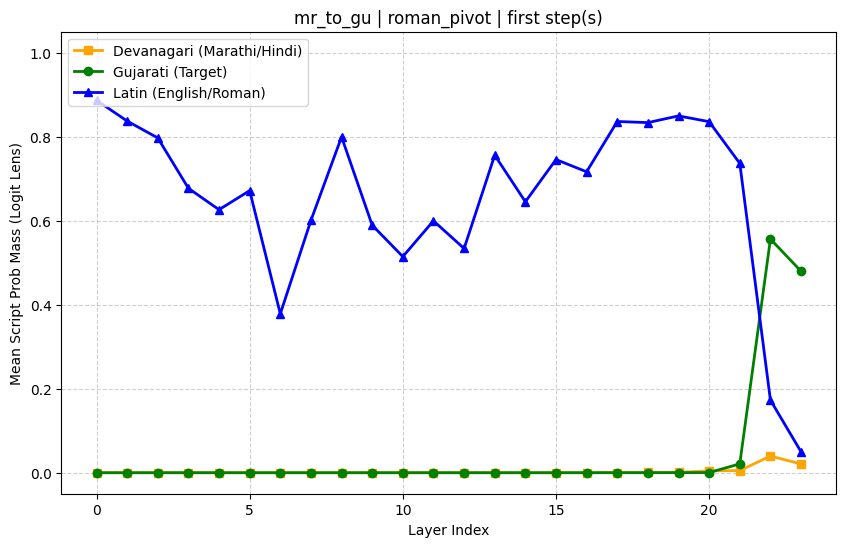

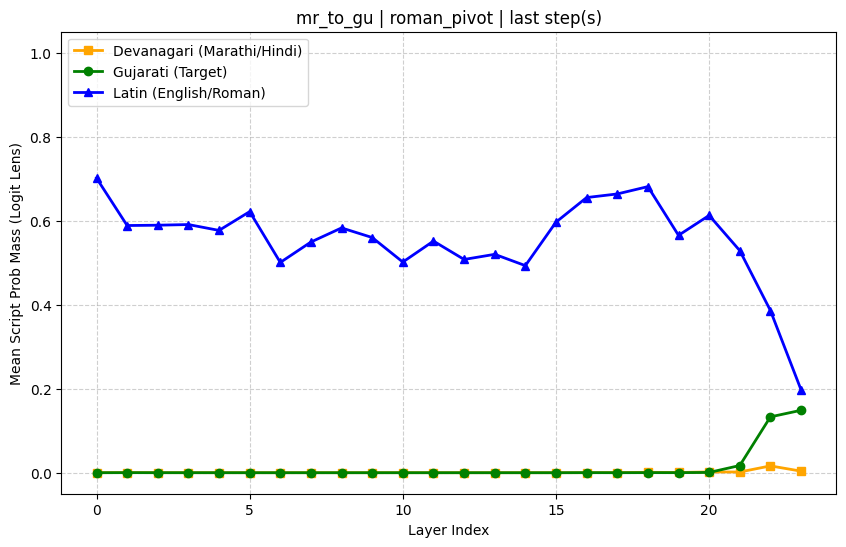

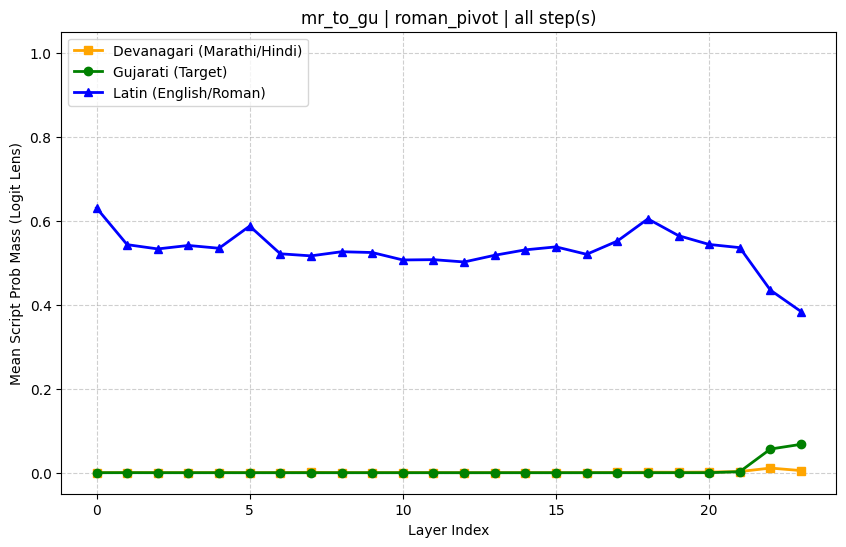

Selected candidate layers: [23, 22, 21]


,layer,latin_direct,latin_pivot,pivot_minus_direct
23,23,0.176917,0.383752,0.206835
22,22,0.269988,0.434637,0.164649
21,21,0.454477,0.535910,0.081433
20,20,0.495488,0.543505,0.048017
19,19,0.532267,0.564449,0.032181
16,16,0.516333,0.520055,0.003722
0,0,0.634586,0.630497,-0.004089
2,2,0.538861,0.532864,-0.005997
3,3,0.552558,0.541127,-0.011431
18,18,0.617203,0.604396,-0.012807


In [84]:
# Choose one pair and one pivot family to inspect first.
SELECTED_PAIR = work_df.iloc[0]["pair"]
INSPECT_CONDITION = "roman_pivot"
PIVOT_SCRIPT = "latin"  # english + roman prompts both expose Latin text explicitly

for view in ["first", "last", "all"]:
    curve_df = aggregate_trace_view(traces_df, SELECTED_PAIR, INSPECT_CONDITION, view=view)
    plot_script_curves(curve_df, f"{SELECTED_PAIR} | {INSPECT_CONDITION} | {view} step(s)")


def select_candidate_layers(
    traces_df: pd.DataFrame,
    pair: str,
    direct_condition: str,
    pivot_condition: str,
    pivot_script: str,
    top_n: int = 3,
):
    direct_df = aggregate_trace_view(traces_df, pair, direct_condition, view="all")
    pivot_df = aggregate_trace_view(traces_df, pair, pivot_condition, view="all")
    merged = direct_df[["layer", pivot_script]].merge(
        pivot_df[["layer", pivot_script]],
        on="layer",
        suffixes=("_direct", "_pivot"),
    )
    merged["pivot_minus_direct"] = merged[f"{pivot_script}_pivot"] - merged[f"{pivot_script}_direct"]
    merged = merged.sort_values("pivot_minus_direct", ascending=False)
    candidate_layers = merged.head(top_n)["layer"].tolist()
    return candidate_layers, merged

candidate_layers, candidate_layer_table = select_candidate_layers(
    traces_df=traces_df,
    pair=SELECTED_PAIR,
    direct_condition="direct",
    pivot_condition=INSPECT_CONDITION,
    pivot_script=PIVOT_SCRIPT,
    top_n=3,
)

print("Selected candidate layers:", candidate_layers)
display(candidate_layer_table)

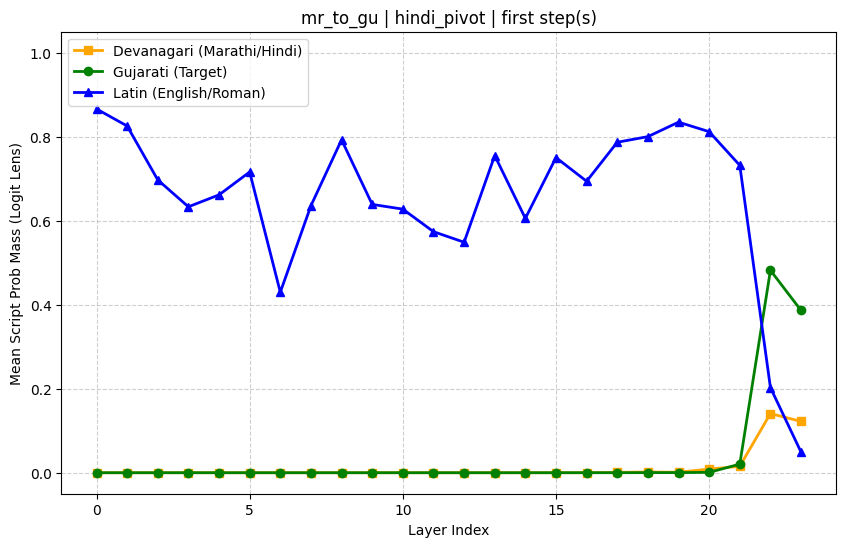

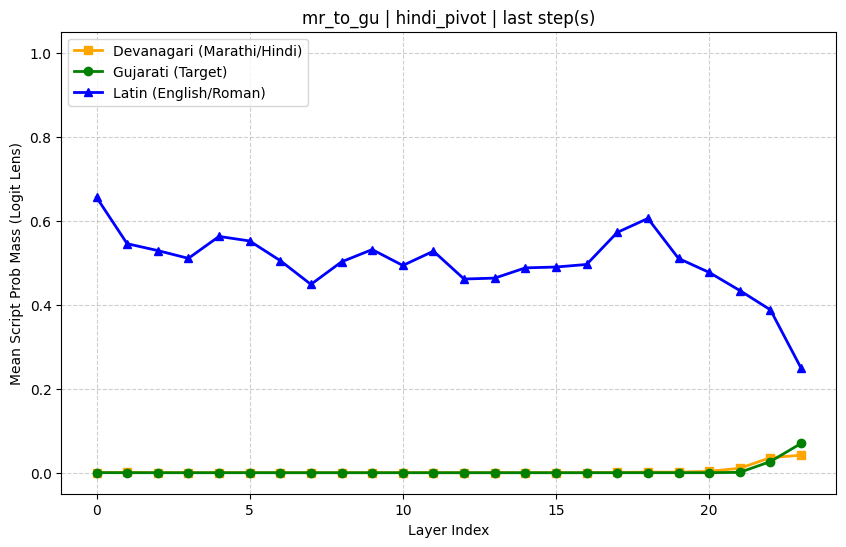

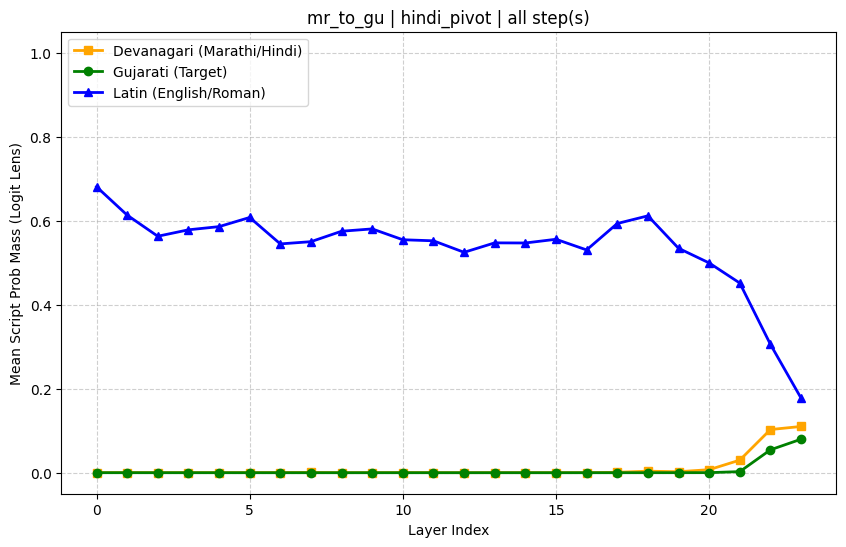

Selected candidate layers: [0, 1, 22]


,layer,latin_direct,latin_pivot,pivot_minus_direct
0,0,0.634586,0.680890,0.046304
1,1,0.574361,0.613391,0.039030
22,22,0.269988,0.305655,0.035667
4,4,0.557536,0.585931,0.028395
3,3,0.552558,0.578354,0.025796
2,2,0.538861,0.563040,0.024178
11,11,0.532084,0.552187,0.020103
9,9,0.565392,0.580520,0.015128
16,16,0.516333,0.530466,0.014133
7,7,0.544823,0.550113,0.005291


In [85]:
# Choose one pair and one pivot family to inspect first.
SELECTED_PAIR = work_df.iloc[0]["pair"]
INSPECT_CONDITION = "hindi_pivot"
PIVOT_SCRIPT = "latin"  # english + roman prompts both expose Latin text explicitly

for view in ["first", "last", "all"]:
    curve_df = aggregate_trace_view(traces_df, SELECTED_PAIR, INSPECT_CONDITION, view=view)
    plot_script_curves(curve_df, f"{SELECTED_PAIR} | {INSPECT_CONDITION} | {view} step(s)")


def select_candidate_layers(
    traces_df: pd.DataFrame,
    pair: str,
    direct_condition: str,
    pivot_condition: str,
    pivot_script: str,
    top_n: int = 3,
):
    direct_df = aggregate_trace_view(traces_df, pair, direct_condition, view="all")
    pivot_df = aggregate_trace_view(traces_df, pair, pivot_condition, view="all")
    merged = direct_df[["layer", pivot_script]].merge(
        pivot_df[["layer", pivot_script]],
        on="layer",
        suffixes=("_direct", "_pivot"),
    )
    merged["pivot_minus_direct"] = merged[f"{pivot_script}_pivot"] - merged[f"{pivot_script}_direct"]
    merged = merged.sort_values("pivot_minus_direct", ascending=False)
    candidate_layers = merged.head(top_n)["layer"].tolist()
    return candidate_layers, merged

candidate_layers, candidate_layer_table = select_candidate_layers(
    traces_df=traces_df,
    pair=SELECTED_PAIR,
    direct_condition="direct",
    pivot_condition=INSPECT_CONDITION,
    pivot_script=PIVOT_SCRIPT,
    top_n=3,
)

print("Selected candidate layers:", candidate_layers)
display(candidate_layer_table)

# **Bengali-Guj Translation**

In [98]:
bengali_gujarati_data =[
    {"pair": "bn_to_gu", "example_id": "bn_gu_w1", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "জল", "source_roman": "jol", "source_devanagari": "जल", "pivot_english": "Water", "pivot_hindi": "पानी", "target_reference": "પાણી"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w2", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "বাড়ি", "source_roman": "bari", "source_devanagari": "बाड़ि", "pivot_english": "House", "pivot_hindi": "घर", "target_reference": "ઘર"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w3", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "বই", "source_roman": "boi", "source_devanagari": "बइ", "pivot_english": "Book", "pivot_hindi": "किताब", "target_reference": "પુસ્તક"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w4", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "সূর্য", "source_roman": "surjo", "source_devanagari": "सूर्य", "pivot_english": "Sun", "pivot_hindi": "सूरज", "target_reference": "સૂર્ય"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w5", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "চাঁদ", "source_roman": "chand", "source_devanagari": "चाँद", "pivot_english": "Moon", "pivot_hindi": "चाँद", "target_reference": "ચંદ્ર"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w6", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "গাছ", "source_roman": "gach", "source_devanagari": "गाछ", "pivot_english": "Tree", "pivot_hindi": "पेड़", "target_reference": "ઝાડ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w7", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "বিড়াল", "source_roman": "biral", "source_devanagari": "बिड़ाल", "pivot_english": "Cat", "pivot_hindi": "बिल्ली", "target_reference": "બિલાડી"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w8", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "কুকুর", "source_roman": "kukur", "source_devanagari": "कुकुर", "pivot_english": "Dog", "pivot_hindi": "कुत्ता", "target_reference": "કૂતરો"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w9", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "দুধ", "source_roman": "dudh", "source_devanagari": "दूध", "pivot_english": "Milk", "pivot_hindi": "दूध", "target_reference": "દૂધ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w10", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "আগুন", "source_roman": "agun", "source_devanagari": "आगुन", "pivot_english": "Fire", "pivot_hindi": "आग", "target_reference": "આગ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w11", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "আকাশ", "source_roman": "akash", "source_devanagari": "आकाश", "pivot_english": "Sky", "pivot_hindi": "आसमान", "target_reference": "આકાશ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w12", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "মানুষ", "source_roman": "manush", "source_devanagari": "मानुष", "pivot_english": "Man", "pivot_hindi": "आदमी", "target_reference": "માણસ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w13", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "মহিলা", "source_roman": "mohila", "source_devanagari": "महिला", "pivot_english": "Woman", "pivot_hindi": "औरत", "target_reference": "સ્ત્રી"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w14", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "খাবার", "source_roman": "khabar", "source_devanagari": "खाबार", "pivot_english": "Food", "pivot_hindi": "खाना", "target_reference": "ખોરાક"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w15", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "রাস্তা", "source_roman": "rasta", "source_devanagari": "रास्ता", "pivot_english": "Road", "pivot_hindi": "सड़क", "target_reference": "રસ્તો"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w16", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "নাম", "source_roman": "nam", "source_devanagari": "नाम", "pivot_english": "Name", "pivot_hindi": "नाम", "target_reference": "નામ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w17", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "সময়", "source_roman": "somoy", "source_devanagari": "समय", "pivot_english": "Time", "pivot_hindi": "समय", "target_reference": "સમય"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w18", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "দিন", "source_roman": "din", "source_devanagari": "दिन", "pivot_english": "Day", "pivot_hindi": "दिन", "target_reference": "દિવસ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w19", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "রাত", "source_roman": "rat", "source_devanagari": "रात", "pivot_english": "Night", "pivot_hindi": "रात", "target_reference": "રાત"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w20", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "লাল", "source_roman": "lal", "source_devanagari": "लाल", "pivot_english": "Red", "pivot_hindi": "लाल", "target_reference": "લાલ"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w21", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "বড়", "source_roman": "boro", "source_devanagari": "बड़ो", "pivot_english": "Big", "pivot_hindi": "बड़ा", "target_reference": "મોટું"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w22", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "ছোট", "source_roman": "choto", "source_devanagari": "छोटो", "pivot_english": "Small", "pivot_hindi": "छोटा", "target_reference": "નાનું"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w23", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "ভালো", "source_roman": "bhalo", "source_devanagari": "भालो", "pivot_english": "Good", "pivot_hindi": "अच्छा", "target_reference": "સારું"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w24", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "পাখি", "source_roman": "pakhi", "source_devanagari": "पाखि", "pivot_english": "Bird", "pivot_hindi": "पक्षी", "target_reference": "પક્ષી"},
    {"pair": "bn_to_gu", "example_id": "bn_gu_w25", "source_lang": "Bengali", "target_lang": "Gujarati", "target_script": "gujarati", "source_native": "চোখ", "source_roman": "chokh", "source_devanagari": "चोख", "pivot_english": "Eye", "pivot_hindi": "आँख", "target_reference": "આંખ"}
]

work_df = pd.DataFrame(bengali_gujarati_data)
display(work_df.head())

,pair,example_id,source_lang,target_lang,target_script,source_native,source_roman,source_devanagari,pivot_english,pivot_hindi,target_reference
0,bn_to_gu,bn_gu_w1,Bengali,Gujarati,gujarati,জল,jol,जल,Water,पानी,પાણી
1,bn_to_gu,bn_gu_w2,Bengali,Gujarati,gujarati,বাড়ি,bari,बाड़ि,House,घर,ઘર
2,bn_to_gu,bn_gu_w3,Bengali,Gujarati,gujarati,বই,boi,बइ,Book,किताब,પુસ્તક
3,bn_to_gu,bn_gu_w4,Bengali,Gujarati,gujarati,সূর্য,surjo,सूर्य,Sun,सूरज,સૂર્ય
4,bn_to_gu,bn_gu_w5,Bengali,Gujarati,gujarati,চাঁদ,chand,चाँद,Moon,चाँद,ચંદ્ર


In [99]:
def prompt_segments_from_condition(row: pd.Series, condition: str):
    target_lang = row["target_lang"]

    if condition == "direct":
        source_lang, source_text = row["source_lang"], row["source_native"]
    elif condition == "english_pivot":
        source_lang, source_text = "English", row["pivot_english"]
    elif condition == "roman_pivot":
        source_lang, source_text = f'{row["source_lang"]} (Romanized)', row["source_roman"]
    elif condition == "deva_script_pivot":
        source_lang, source_text = f'{row["source_lang"]} (Devanagari)', row["source_devanagari"]
    elif condition == "hindi_pivot":
        source_lang, source_text = "Hindi", row["pivot_hindi"]
    else:
        raise ValueError(f"Unknown condition: {condition}")

    prefix = f'{source_lang}: "'
    suffix = f'" - {target_lang}: "'
    return prefix, source_text, suffix

def build_romanlens_few_shot_prompt(df: pd.DataFrame, target_index: int, condition: str, num_shots: int = 5):
    prompt = ""
    start_idx = max(0, target_index - num_shots)
    example_rows = df.iloc[start_idx:target_index]
    
    for _, row in example_rows.iterrows():
        prefix, source_text, suffix = prompt_segments_from_condition(row, condition)
        target_text = row["target_reference"]
        prompt += f"{prefix}{source_text}{suffix}{target_text}\"\n"
        
    target_row = df.iloc[target_index]
    prefix, source_text, suffix = prompt_segments_from_condition(target_row, condition)
    prompt += prefix + source_text + suffix
    
    return prompt

In [100]:
def char_script(ch: str) -> str:
    try:
        name = unicodedata.name(ch).upper()
        if "BENGALI" in name: return "bengali"
        if "GUJARATI" in name: return "gujarati"
        if "DEVANAGARI" in name: return "devanagari"
        if "LATIN" in name: return "latin"
    except ValueError:
        return None
    return None

def dominant_script_for_token_text(token_text: str) -> str:
    cleaned = token_text.replace("▁", "").replace("Ġ", "").replace(" ", "").strip()
    if not cleaned: return "other"
        
    counts = Counter()
    for ch in cleaned:
        s = char_script(ch)
        if s: counts[s] += 1
            
    if not counts: return "other"
    if len(counts) > 1: return "mixed"
    return counts.most_common(1)[0][0]

def build_or_load_vocab_script_cache(tokenizer, model_name: str):
    safe_name = model_name.replace("/", "__")
    cache_path = CACHE_DIR / f"vocab_script_map_bn_gu__{safe_name}.pkl"

    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)
            
    vocab_size = len(tokenizer)
    id_to_bucket, bucket_to_ids = {}, defaultdict(list)
    
    for token_id in tqdm(range(vocab_size), desc="Mapping Vocab to Scripts"):
        token_text = tokenizer.decode([token_id], skip_special_tokens=False)
        bucket = dominant_script_for_token_text(token_text)
        id_to_bucket[token_id] = bucket
        bucket_to_ids[bucket].append(token_id)
        
    data = {"id_to_bucket": id_to_bucket, "bucket_to_ids": dict(bucket_to_ids)}
    with open(cache_path, "wb") as f: pickle.dump(data, f)
    return data

vocab_script_cache = build_or_load_vocab_script_cache(tokenizer, MODEL_NAME)
bucket_to_ids = vocab_script_cache["bucket_to_ids"]

logit_dim = model.lm_head.out_features
SCRIPT_BUCKETS =["latin", "devanagari", "bengali", "gujarati", "mixed", "other"]

SCRIPT_MASKS = {}
for bucket in SCRIPT_BUCKETS:
    mask = torch.zeros(logit_dim, dtype=torch.bool, device=DEVICE)
    ids = bucket_to_ids.get(bucket,[])
    if ids:
        valid_ids =[i for i in ids if i < logit_dim]
        mask[torch.tensor(valid_ids, dtype=torch.long, device=DEVICE)] = True
    SCRIPT_MASKS[bucket] = mask

print("Masks aligned to logit dim:", logit_dim)
print("Token counts per script:", {b: int(m.sum().item()) for b, m in SCRIPT_MASKS.items()})

Mapping Vocab to Scripts: 100%|██████████| 151665/151665 [00:01<00:00, 126319.36it/s]


Masks aligned to logit dim: 151936
Token counts per script: {'latin': 94759, 'devanagari': 71, 'bengali': 47, 'gujarati': 16, 'mixed': 0, 'other': 56772}


In [101]:
baseline_rows, all_trace_rows, all_token_rows = [], [],[]

for idx, row in tqdm(work_df.iterrows(), total=len(work_df), desc="Evaluating Model"):
    for condition in PROMPT_CONDITIONS:
        
        # 1. Few-Shot Build
        full_prompt = build_romanlens_few_shot_prompt(work_df, target_index=idx, condition=condition, num_shots=5)
        input_ids = tokenizer.encode(full_prompt, return_tensors="pt").to(DEVICE)
        
        # 2. Generate with Logit Lens Tracing
        pred_text, trace_df, token_df, _ = greedy_generate_with_traces(model, tokenizer, input_ids)

        # 3. Clean prediction (Stop at quote or newline)
        clean_pred = pred_text.split('"')[0].split('\n')[0].strip()

        # 4. Store Meta
        trace_df["example_id"] = row["example_id"]
        trace_df["pair"] = row["pair"]
        trace_df["condition"] = condition

        token_df["example_id"] = row["example_id"]
        token_df["condition"] = condition

        all_trace_rows.append(trace_df)
        all_token_rows.append(token_df)

        baseline_rows.append({
            "pair": row["pair"],
            "example_id": row["example_id"],
            "condition": condition,
            "reference": row["target_reference"],
            "prediction": clean_pred,
            "exact_match": int(normalize_text(clean_pred) == normalize_text(row["target_reference"])),
            "char_f1": char_f1(clean_pred, row["target_reference"]),
            "target_script_ratio": target_script_ratio(clean_pred, row["target_script"]),
        })

baseline_df = pd.DataFrame(baseline_rows)
traces_df = pd.concat(all_trace_rows, ignore_index=True) if all_trace_rows else pd.DataFrame()

print("\n--- Summary Results ---")
display(baseline_df.groupby(["pair", "condition"])[["exact_match", "char_f1", "target_script_ratio"]].mean())

Evaluating Model: 100%|██████████| 25/25 [03:53<00:00,  9.33s/it]


--- Summary Results ---


exact_match   char_f1  target_script_ratio
pair     condition                                                    
bn_to_gu deva_script_pivot         0.20  0.451059             0.790000
         direct                    0.12  0.360170             0.740000
         english_pivot             0.04  0.272448             1.000000
         hindi_pivot               0.20  0.455734             0.853333
         roman_pivot               0.04  0.404112             0.960000

In [102]:
def aggregate_trace_view(traces_df: pd.DataFrame, condition: str, view: str = "first"):
    # Filter explicitly for the Bengali-Gujarati pair
    subset = traces_df[(traces_df["pair"] == "bn_to_gu") & (traces_df["condition"] == condition)].copy()
    
    if subset.empty:
        print(f"No trace data found for {condition}")
        return subset

    if view == "first":
        subset = subset[subset["step"] == 0]
    elif view == "last":
        last_steps = subset.groupby("example_id")["step"].transform("max")
        subset = subset[subset["step"] == last_steps]

    return subset.groupby("layer", as_index=False)[SCRIPT_BUCKETS].mean().sort_values("layer")


def plot_script_curves(curve_df: pd.DataFrame, title: str):
    if curve_df.empty: return
        
    plt.figure(figsize=(10, 6))
    
    # Custom styling for Bengali to Gujarati pipelines
    styles = {
        "bengali": {"color": "blue", "marker": "s", "label": "Bengali (Native Source)"},
        "gujarati": {"color": "green", "marker": "o", "label": "Gujarati (Target)"},
        "devanagari": {"color": "orange", "marker": "d", "label": "Devanagari (Hindi/Mapped Pivot)"},
        "latin": {"color": "red", "marker": "^", "label": "Latin (English/Romanized Pivot)"}
    }

    for bucket, style in styles.items():
        if bucket in curve_df.columns:
            plt.plot(curve_df["layer"], curve_df[bucket], marker=style["marker"], 
                     color=style["color"], label=style["label"], linewidth=2)

    plt.title(title, fontsize=13, pad=15)
    plt.xlabel("Transformer Layer Index", fontsize=11)
    plt.ylabel("Mean Script Probability Mass", fontsize=11)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

# **1st token Viz**

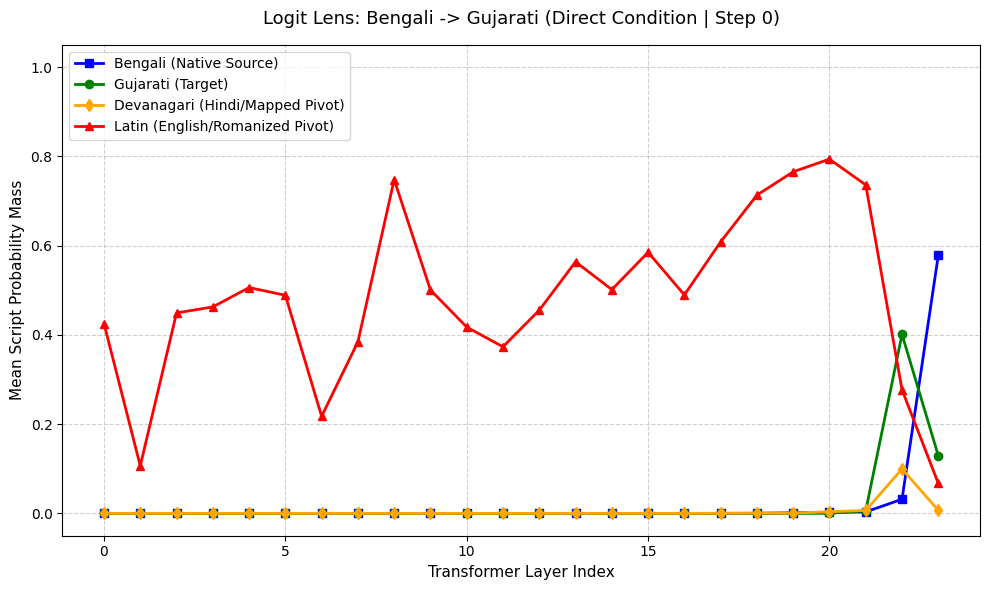

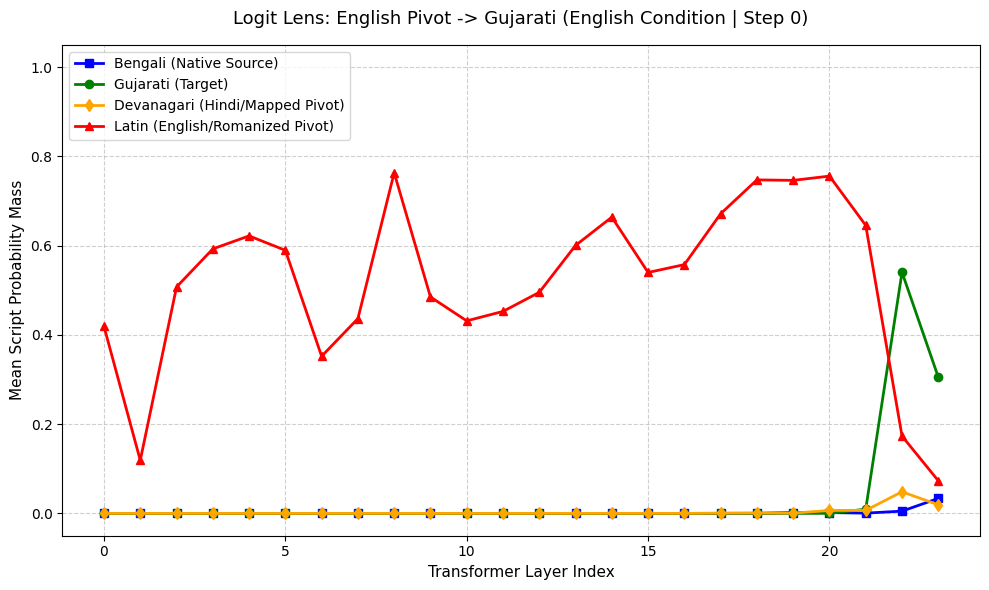

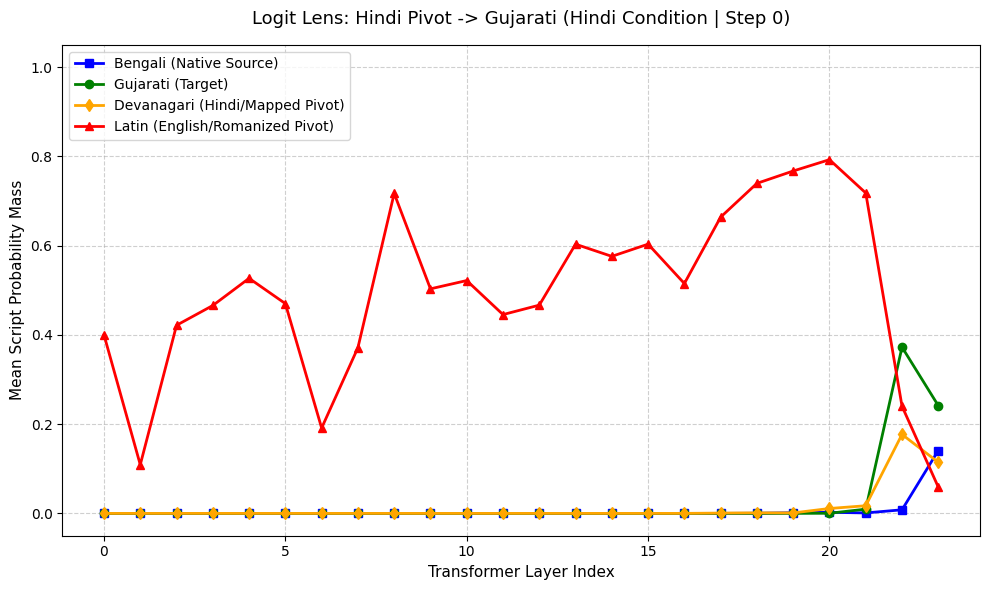

In [103]:
# 1. Native condition (Bengali to Gujarati)
curve_direct = aggregate_trace_view(traces_df, condition="direct", view="first")
plot_script_curves(curve_direct, "Logit Lens: Bengali -> Gujarati (Direct Condition | Step 0)")

# 2. English Pivot condition (Latin to Gujarati)
curve_english = aggregate_trace_view(traces_df, condition="english_pivot", view="first")
plot_script_curves(curve_english, "Logit Lens: English Pivot -> Gujarati (English Condition | Step 0)")

# 3. Hindi Pivot condition (Devanagari to Gujarati)
curve_hindi = aggregate_trace_view(traces_df, condition="hindi_pivot", view="first")
plot_script_curves(curve_hindi, "Logit Lens: Hindi Pivot -> Gujarati (Hindi Condition | Step 0)")

# **Last Token Viz**

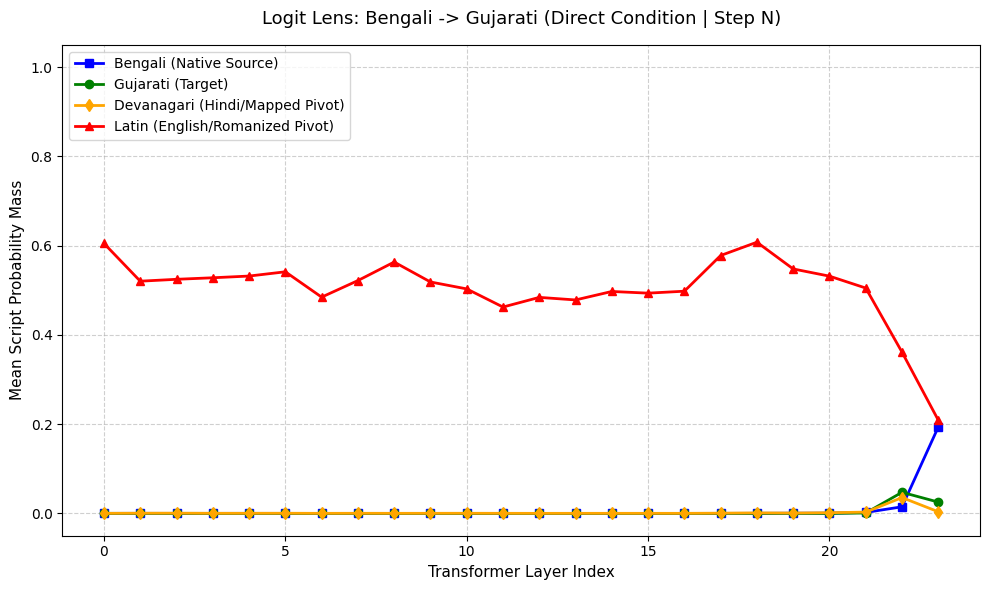

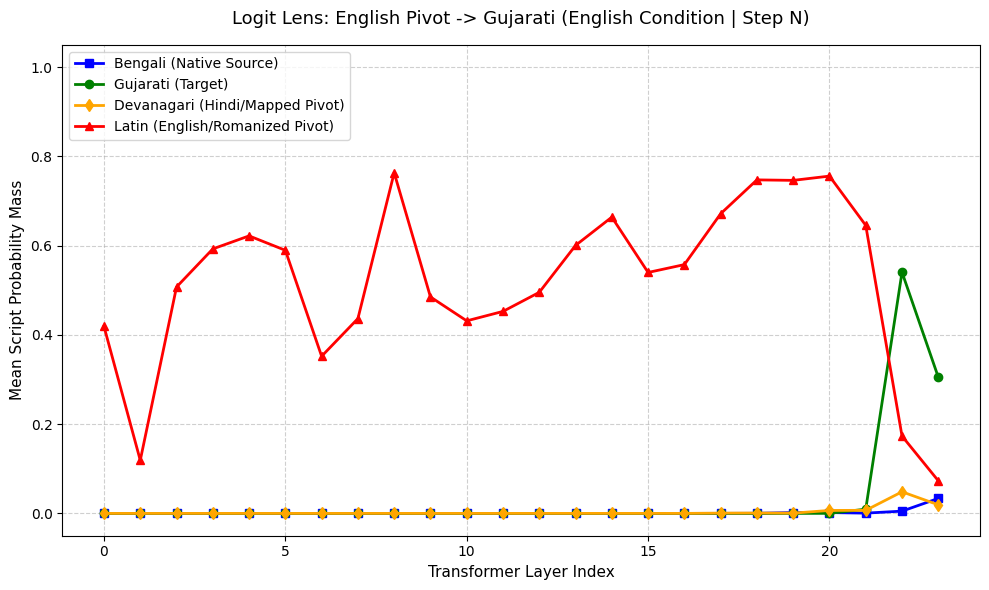

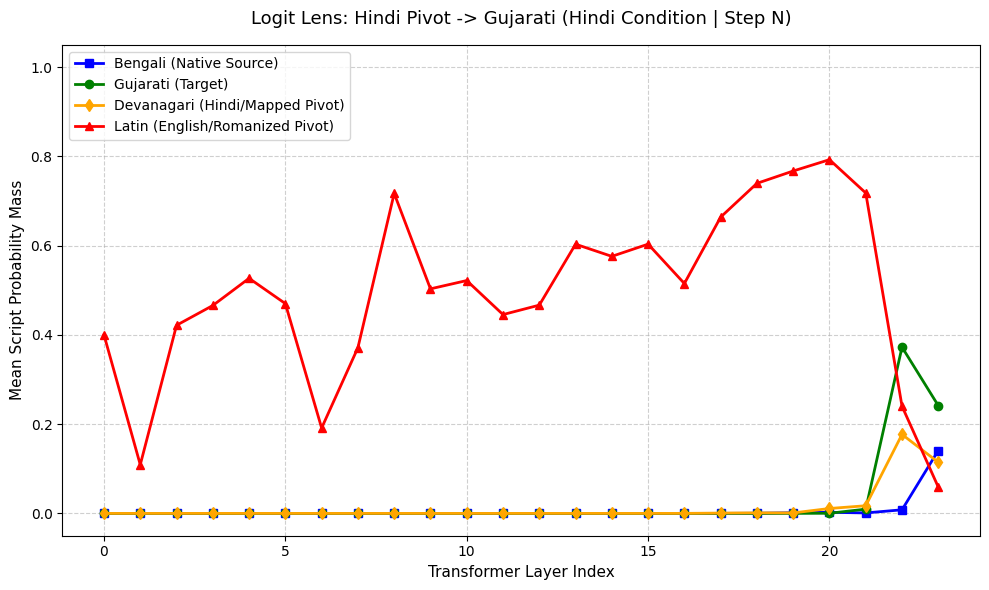

In [104]:
# 1. Native condition (Bengali to Gujarati)
curve_direct = aggregate_trace_view(traces_df, condition="direct", view="Last")
plot_script_curves(curve_direct, "Logit Lens: Bengali -> Gujarati (Direct Condition | Step N)")

# 2. English Pivot condition (Latin to Gujarati)
curve_english = aggregate_trace_view(traces_df, condition="english_pivot", view="first")
plot_script_curves(curve_english, "Logit Lens: English Pivot -> Gujarati (English Condition | Step N)")

# 3. Hindi Pivot condition (Devanagari to Gujarati)
curve_hindi = aggregate_trace_view(traces_df, condition="hindi_pivot", view="first")
plot_script_curves(curve_hindi, "Logit Lens: Hindi Pivot -> Gujarati (Hindi Condition | Step N)")

# **Bengali-Tamil Translation**

In [86]:
import pandas as pd

bengali_tamil_data =[
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w1",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "জল",
        "source_roman": "jol",
        "source_devanagari": "जल",
        "pivot_english": "Water",
        "pivot_hindi": "पानी",
        "target_reference": "தண்ணீர்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w2",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "বাড়ি",
        "source_roman": "bari",
        "source_devanagari": "बाड़ि",
        "pivot_english": "House",
        "pivot_hindi": "घर",
        "target_reference": "வீடு"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w3",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "বই",
        "source_roman": "boi",
        "source_devanagari": "बइ",
        "pivot_english": "Book",
        "pivot_hindi": "किताब",
        "target_reference": "புத்தகம்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w4",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "সূর্য",
        "source_roman": "surjo",
        "source_devanagari": "सूर्य",
        "pivot_english": "Sun",
        "pivot_hindi": "सूरज",
        "target_reference": "சூரியன்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w5",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "চাঁদ",
        "source_roman": "chand",
        "source_devanagari": "चाँद",
        "pivot_english": "Moon",
        "pivot_hindi": "चाँद",
        "target_reference": "நிலா"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w6",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "গাছ",
        "source_roman": "gach",
        "source_devanagari": "गाछ",
        "pivot_english": "Tree",
        "pivot_hindi": "पेड़",
        "target_reference": "மரம்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w7",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "বিড়াল",
        "source_roman": "biral",
        "source_devanagari": "बिड़ाल",
        "pivot_english": "Cat",
        "pivot_hindi": "बिल्ली",
        "target_reference": "பூனை"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w8",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "কুকুর",
        "source_roman": "kukur",
        "source_devanagari": "कुकुर",
        "pivot_english": "Dog",
        "pivot_hindi": "कुत्ता",
        "target_reference": "நாய்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w9",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "দুধ",
        "source_roman": "dudh",
        "source_devanagari": "दूध",
        "pivot_english": "Milk",
        "pivot_hindi": "दूध",
        "target_reference": "பால்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w10",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "আগুন",
        "source_roman": "agun",
        "source_devanagari": "आगुन",
        "pivot_english": "Fire",
        "pivot_hindi": "आग",
        "target_reference": "நெருப்பு"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w11",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "আকাশ",
        "source_roman": "akash",
        "source_devanagari": "आकाश",
        "pivot_english": "Sky",
        "pivot_hindi": "आसमान",
        "target_reference": "வானம்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w12",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "মানুষ",
        "source_roman": "manush",
        "source_devanagari": "मानुष",
        "pivot_english": "Man",
        "pivot_hindi": "आदमी",
        "target_reference": "மனிதன்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w13",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "মহিলা",
        "source_roman": "mohila",
        "source_devanagari": "महिला",
        "pivot_english": "Woman",
        "pivot_hindi": "औरत",
        "target_reference": "பெண்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w14",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "খাবার",
        "source_roman": "khabar",
        "source_devanagari": "खाबार",
        "pivot_english": "Food",
        "pivot_hindi": "खाना",
        "target_reference": "உணவு"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w15",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "রাস্তা",
        "source_roman": "rasta",
        "source_devanagari": "रास्ता",
        "pivot_english": "Road",
        "pivot_hindi": "सड़क",
        "target_reference": "சாலை"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w16",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "নাম",
        "source_roman": "nam",
        "source_devanagari": "नाम",
        "pivot_english": "Name",
        "pivot_hindi": "नाम",
        "target_reference": "பெயர்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w17",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "সময়",
        "source_roman": "somoy",
        "source_devanagari": "समय",
        "pivot_english": "Time",
        "pivot_hindi": "समय",
        "target_reference": "நேரம்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w18",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "দিন",
        "source_roman": "din",
        "source_devanagari": "दिन",
        "pivot_english": "Day",
        "pivot_hindi": "दिन",
        "target_reference": "நாள்"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w19",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "রাত",
        "source_roman": "rat",
        "source_devanagari": "रात",
        "pivot_english": "Night",
        "pivot_hindi": "रात",
        "target_reference": "இரவு"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w20",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "লাল",
        "source_roman": "lal",
        "source_devanagari": "लाल",
        "pivot_english": "Red",
        "pivot_hindi": "लाल",
        "target_reference": "சிவப்பு"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w21",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "বড়",
        "source_roman": "boro",
        "source_devanagari": "बड़ो",
        "pivot_english": "Big",
        "pivot_hindi": "बड़ा",
        "target_reference": "பெரிய"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w22",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "ছোট",
        "source_roman": "choto",
        "source_devanagari": "छोटो",
        "pivot_english": "Small",
        "pivot_hindi": "छोटा",
        "target_reference": "சிறிய"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w23",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "ভালো",
        "source_roman": "bhalo",
        "source_devanagari": "भालो",
        "pivot_english": "Good",
        "pivot_hindi": "अच्छा",
        "target_reference": "நல்ல"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w24",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "পাখি",
        "source_roman": "pakhi",
        "source_devanagari": "पाखि",
        "pivot_english": "Bird",
        "pivot_hindi": "पक्षी",
        "target_reference": "பறவை"
    },
    {
        "pair": "bn_to_ta",
        "example_id": "bn_ta_w25",
        "source_lang": "Bengali",
        "target_lang": "Tamil",
        "target_script": "tamil",
        "source_native": "চোখ",
        "source_roman": "chokh",
        "source_devanagari": "चोख",
        "pivot_english": "Eye",
        "pivot_hindi": "आँख",
        "target_reference": "கண்"
    }
]

work_df = pd.DataFrame(bengali_tamil_data)
display(work_df.head())

,pair,example_id,source_lang,target_lang,target_script,source_native,source_roman,source_devanagari,pivot_english,pivot_hindi,target_reference
0,bn_to_ta,bn_ta_w1,Bengali,Tamil,tamil,জল,jol,जल,Water,पानी,தண்ணீர்
1,bn_to_ta,bn_ta_w2,Bengali,Tamil,tamil,বাড়ি,bari,बाड़ि,House,घर,வீடு
2,bn_to_ta,bn_ta_w3,Bengali,Tamil,tamil,বই,boi,बइ,Book,किताब,புத்தகம்
3,bn_to_ta,bn_ta_w4,Bengali,Tamil,tamil,সূর্য,surjo,सूर्य,Sun,सूरज,சூரியன்
4,bn_to_ta,bn_ta_w5,Bengali,Tamil,tamil,চাঁদ,chand,चाँद,Moon,चाँद,நிலா


In [87]:
def char_script(ch: str) -> str:
    try:
        name = unicodedata.name(ch).upper()
        if "BENGALI" in name:          # Track the Native Source
            return "bengali"
        if "TAMIL" in name:            # Track the Target
            return "tamil"
        if "DEVANAGARI" in name:       # Track the Devanagari & Hindi Pivot
            return "devanagari"
        if "LATIN" in name:            # Track the English & Roman Pivot
            return "latin"
    except ValueError:
        return None
    return None

SCRIPT_BUCKETS =["latin", "devanagari", "bengali", "tamil", "mixed", "other"]

In [89]:
def prompt_segments_from_condition(row: pd.Series, condition: str):
    target_lang = row["target_lang"]

    if condition == "direct":
        source_lang, source_text = row["source_lang"], row["source_native"]
    elif condition == "english_pivot":
        source_lang, source_text = "English", row["pivot_english"]
    elif condition == "roman_pivot":
        source_lang, source_text = f'{row["source_lang"]} (Romanized)', row["source_roman"]
    elif condition == "deva_script_pivot":
        source_lang, source_text = f'{row["source_lang"]} (Devanagari)', row["source_devanagari"]
    elif condition == "hindi_pivot":
        source_lang, source_text = "Hindi", row["pivot_hindi"]
    else:
        raise ValueError(f"Unknown condition: {condition}")

    prefix = f'{source_lang}: "'
    suffix = f'" - {target_lang}: "'
    return prefix, source_text, suffix

def build_romanlens_few_shot_prompt(df: pd.DataFrame, target_index: int, condition: str, num_shots: int = 5):
    prompt = ""
    start_idx = max(0, target_index - num_shots)
    example_rows = df.iloc[start_idx:target_index]
    
    for _, row in example_rows.iterrows():
        prefix, source_text, suffix = prompt_segments_from_condition(row, condition)
        target_text = row["target_reference"]
        prompt += f"{prefix}{source_text}{suffix}{target_text}\"\n"
        
    target_row = df.iloc[target_index]
    prefix, source_text, suffix = prompt_segments_from_condition(target_row, condition)
    prompt += prefix + source_text + suffix
    
    return prompt

In [90]:
def char_script(ch: str) -> str:
    try:
        name = unicodedata.name(ch).upper()
        if "BENGALI" in name: return "bengali"
        if "TAMIL" in name: return "tamil"
        if "DEVANAGARI" in name: return "devanagari"
        if "LATIN" in name: return "latin"
    except ValueError:
        return None
    return None

def dominant_script_for_token_text(token_text: str) -> str:
    cleaned = token_text.replace("▁", "").replace("Ġ", "").replace(" ", "").strip()
    if not cleaned: return "other"
        
    counts = Counter()
    for ch in cleaned:
        s = char_script(ch)
        if s: counts[s] += 1
            
    if not counts: return "other"
    if len(counts) > 1: return "mixed"
    return counts.most_common(1)[0][0]

def build_or_load_vocab_script_cache(tokenizer, model_name: str):
    safe_name = model_name.replace("/", "__")
    cache_path = CACHE_DIR / f"vocab_script_map_bn_ta__{safe_name}.pkl"

    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)
            
    vocab_size = len(tokenizer)
    id_to_bucket, bucket_to_ids = {}, defaultdict(list)
    
    for token_id in tqdm(range(vocab_size), desc="Mapping Vocab"):
        token_text = tokenizer.decode([token_id], skip_special_tokens=False)
        bucket = dominant_script_for_token_text(token_text)
        id_to_bucket[token_id] = bucket
        bucket_to_ids[bucket].append(token_id)
        
    data = {"id_to_bucket": id_to_bucket, "bucket_to_ids": dict(bucket_to_ids)}
    with open(cache_path, "wb") as f: pickle.dump(data, f)
    return data

vocab_script_cache = build_or_load_vocab_script_cache(tokenizer, MODEL_NAME)
bucket_to_ids = vocab_script_cache["bucket_to_ids"]

logit_dim = model.lm_head.out_features
SCRIPT_BUCKETS =["latin", "devanagari", "bengali", "tamil", "mixed", "other"]

SCRIPT_MASKS = {}
for bucket in SCRIPT_BUCKETS:
    mask = torch.zeros(logit_dim, dtype=torch.bool, device=DEVICE)
    ids = bucket_to_ids.get(bucket,[])
    if ids:
        valid_ids = [i for i in ids if i < logit_dim]
        mask[torch.tensor(valid_ids, dtype=torch.long, device=DEVICE)] = True
    SCRIPT_MASKS[bucket] = mask

print("Masks aligned to logit dim:", logit_dim)
print("Token counts per script:", {b: int(m.sum().item()) for b, m in SCRIPT_MASKS.items()})

Masks aligned to logit dim: 151936
Token counts per script: {'latin': 94759, 'devanagari': 71, 'bengali': 47, 'tamil': 30, 'mixed': 0, 'other': 56758}


In [91]:
def apply_final_norm(model, hidden_3d):
    base = model.model if hasattr(model, "model") else model
    if hasattr(base, "norm"): return base.norm(hidden_3d)
    if hasattr(base, "final_layernorm"): return base.final_layernorm(hidden_3d)
    if hasattr(base, "ln_f"): return base.ln_f(hidden_3d)
    return hidden_3d

def hidden_to_logits(model, hidden_2d):
    hidden_3d = hidden_2d.unsqueeze(1)
    hidden_3d = apply_final_norm(model, hidden_3d)
    hidden_2d = hidden_3d[:, -1, :]
    return model.lm_head(hidden_2d)

def aggregate_script_mass_from_logits(logits_1d: torch.Tensor, script_masks: dict):
    probs = torch.softmax(logits_1d, dim=-1)
    return {bucket: float(probs[mask].sum().item()) for bucket, mask in script_masks.items()}

@torch.no_grad()
def greedy_generate_with_traces(model, tokenizer, input_ids, max_new_tokens=MAX_NEW_TOKENS):
    generated = input_ids.clone()
    step_rows, token_rows = [],[]

    for step_idx in range(max_new_tokens):
        outputs = model(input_ids=generated, output_hidden_states=True, use_cache=False)
        next_token_logits = outputs.logits[:, -1, :]
        next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        next_token_text = tokenizer.decode(next_token_id[0].tolist(), skip_special_tokens=True)

        hidden_states = outputs.hidden_states[1:]
        for layer_idx, layer_h in enumerate(hidden_states):
            last_hidden = layer_h[:, -1, :]
            layer_logits = hidden_to_logits(model, last_hidden)[0]
            masses = aggregate_script_mass_from_logits(layer_logits, SCRIPT_MASKS)
            
            row = {"step": step_idx, "layer": layer_idx}
            row.update(masses)
            step_rows.append(row)

        token_rows.append({
            "step": step_idx, "next_token_id": int(next_token_id.item()), "next_token_text": next_token_text
        })
        generated = torch.cat([generated, next_token_id], dim=-1)

        if tokenizer.eos_token_id is not None and int(next_token_id.item()) == tokenizer.eos_token_id:
            break

    gen_ids = generated[0, input_ids.shape[1]:].tolist()
    generated_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    return generated_text, pd.DataFrame(step_rows), pd.DataFrame(token_rows), generated

In [92]:
baseline_rows, all_trace_rows, all_token_rows = [], [],[]

for idx, row in tqdm(work_df.iterrows(), total=len(work_df), desc="Evaluating Models"):
    for condition in PROMPT_CONDITIONS:
        
        # 1. Few-Shot Build
        full_prompt = build_romanlens_few_shot_prompt(work_df, target_index=idx, condition=condition, num_shots=5)
        input_ids = tokenizer.encode(full_prompt, return_tensors="pt").to(DEVICE)
        
        # 2. Generate with Logit Lens Tracing
        pred_text, trace_df, token_df, _ = greedy_generate_with_traces(model, tokenizer, input_ids)

        # 3. Clean prediction (Stop at quote or newline)
        clean_pred = pred_text.split('"')[0].split('\n')[0].strip()

        # 4. Store Meta
        trace_df["example_id"] = row["example_id"]
        trace_df["pair"] = row["pair"]
        trace_df["condition"] = condition

        token_df["example_id"] = row["example_id"]
        token_df["condition"] = condition

        all_trace_rows.append(trace_df)
        all_token_rows.append(token_df)

        baseline_rows.append({
            "pair": row["pair"],
            "example_id": row["example_id"],
            "condition": condition,
            "reference": row["target_reference"],
            "prediction": clean_pred,
            "exact_match": int(normalize_text(clean_pred) == normalize_text(row["target_reference"])),
            "char_f1": char_f1(clean_pred, row["target_reference"]),
            "target_script_ratio": target_script_ratio(clean_pred, row["target_script"]),
        })

baseline_df = pd.DataFrame(baseline_rows)
traces_df = pd.concat(all_trace_rows, ignore_index=True) if all_trace_rows else pd.DataFrame()

print("\n--- Summary Results ---")
display(baseline_df.groupby(["pair", "condition"])[["exact_match", "char_f1", "target_script_ratio"]].mean())

Evaluating Models: 100%|██████████| 25/25 [03:51<00:00,  9.25s/it]


--- Summary Results ---


exact_match   char_f1  target_script_ratio
pair     condition                                                    
bn_to_ta deva_script_pivot          0.0  0.253100                 0.96
         direct                     0.0  0.159322                 0.76
         english_pivot              0.0  0.217920                 0.96
         hindi_pivot                0.0  0.205345                 0.96
         roman_pivot                0.0  0.212883                 0.96

In [93]:
def aggregate_trace_view(traces_df: pd.DataFrame, condition: str, view: str = "first"):
    subset = traces_df[(traces_df["pair"] == "bn_to_ta") & (traces_df["condition"] == condition)].copy()
    
    if subset.empty:
        return subset

    if view == "first":
        subset = subset[subset["step"] == 0]
    elif view == "last":
        last_steps = subset.groupby("example_id")["step"].transform("max")
        subset = subset[subset["step"] == last_steps]

    return subset.groupby("layer", as_index=False)[SCRIPT_BUCKETS].mean().sort_values("layer")


def plot_script_curves(curve_df: pd.DataFrame, title: str):
    if curve_df.empty: return
        
    plt.figure(figsize=(10, 6))
    
    # Custom styling for Bengali to Tamil pipelines
    styles = {
        "bengali": {"color": "blue", "marker": "s", "label": "Bengali (Native)"},
        "tamil": {"color": "green", "marker": "o", "label": "Tamil (Target)"},
        "devanagari": {"color": "orange", "marker": "d", "label": "Devanagari (Hindi/Mapped)"},
        "latin": {"color": "red", "marker": "^", "label": "Latin (English/Romanized)"}
    }

    for bucket, style in styles.items():
        if bucket in curve_df.columns:
            plt.plot(curve_df["layer"], curve_df[bucket], marker=style["marker"], 
                     color=style["color"], label=style["label"], linewidth=2)

    plt.title(title, fontsize=13, pad=15)
    plt.xlabel("Transformer Layer Index", fontsize=11)
    plt.ylabel("Mean Script Probability Mass", fontsize=11)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

# **1st token Viz**

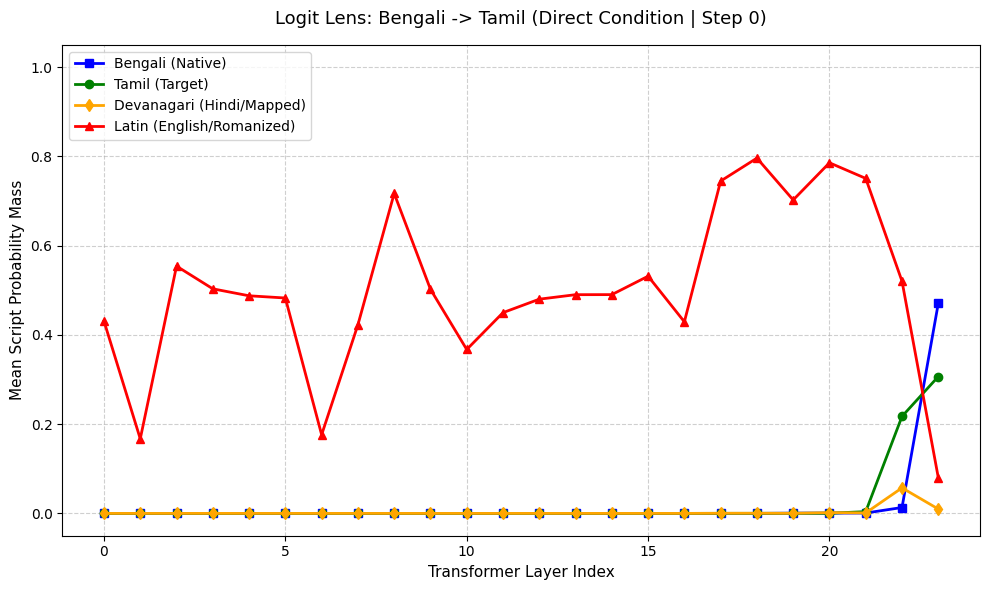

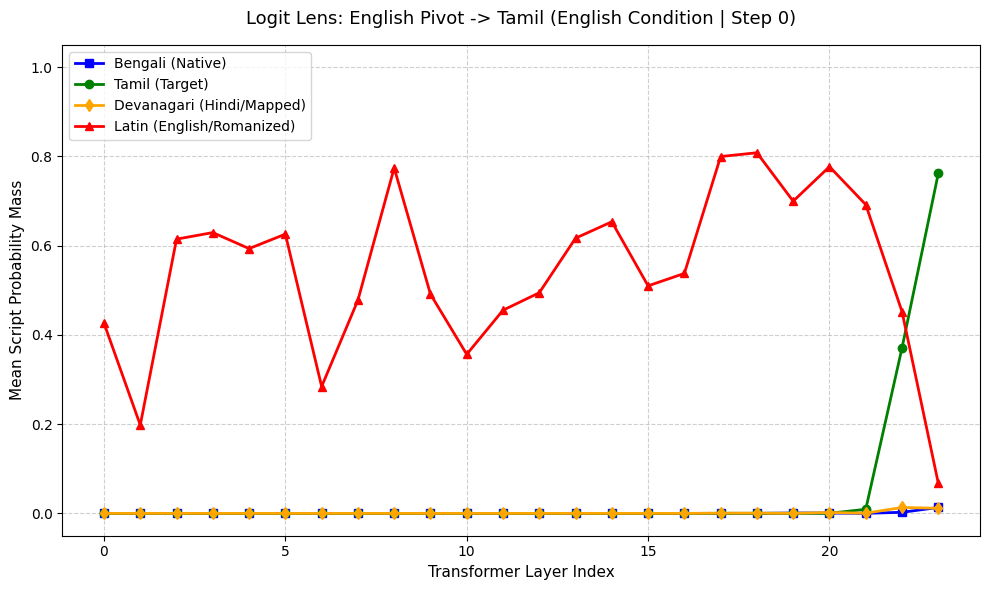

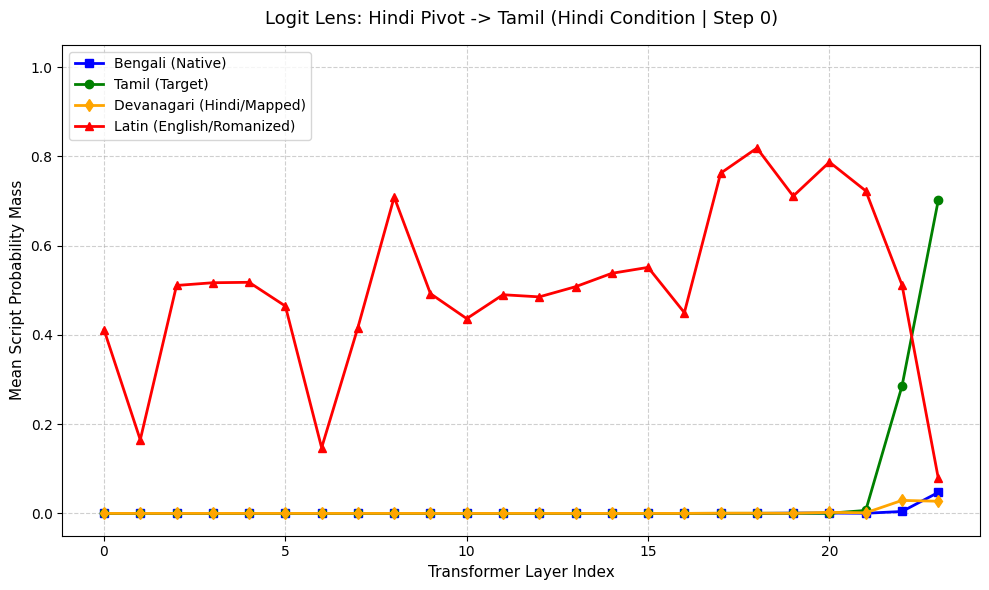

In [96]:
# 1. Native condition (Bengali to Tamil)
curve_direct = aggregate_trace_view(traces_df, condition="direct", view="first")
plot_script_curves(curve_direct, "Logit Lens: Bengali -> Tamil (Direct Condition | Step 0)")

# 2. English Pivot condition (Latin to Tamil)
curve_english = aggregate_trace_view(traces_df, condition="english_pivot", view="first")
plot_script_curves(curve_english, "Logit Lens: English Pivot -> Tamil (English Condition | Step 0)")

# 3. Hindi Pivot condition (Devanagari to Tamil)
curve_hindi = aggregate_trace_view(traces_df, condition="hindi_pivot", view="first")
plot_script_curves(curve_hindi, "Logit Lens: Hindi Pivot -> Tamil (Hindi Condition | Step 0)")

# **Last token Viz**

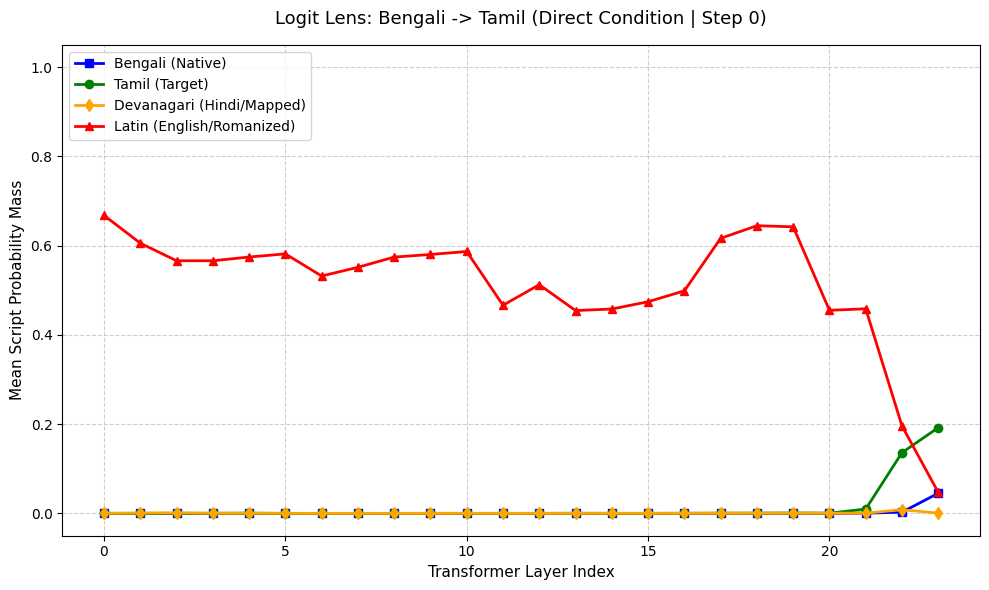

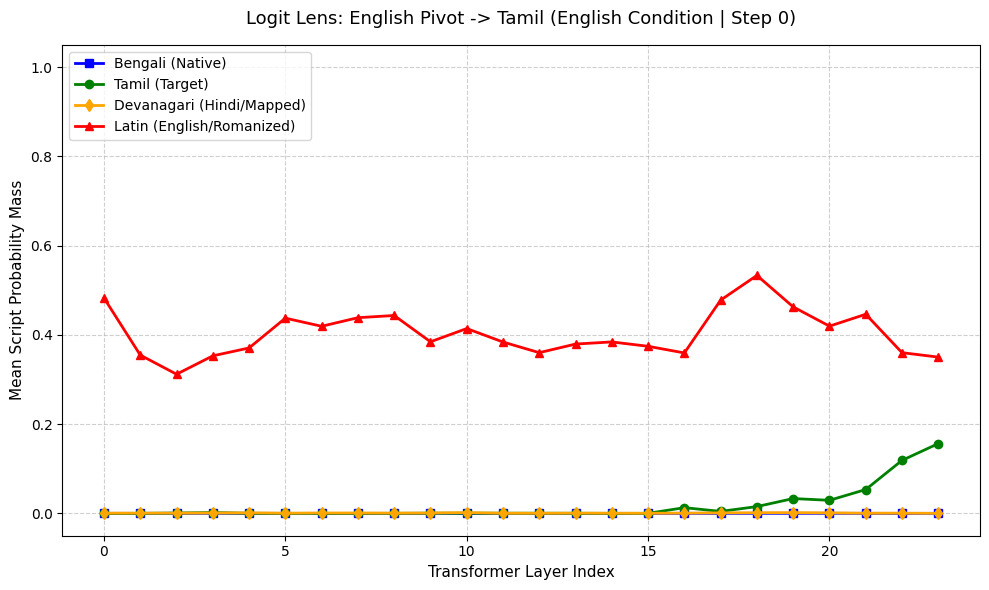

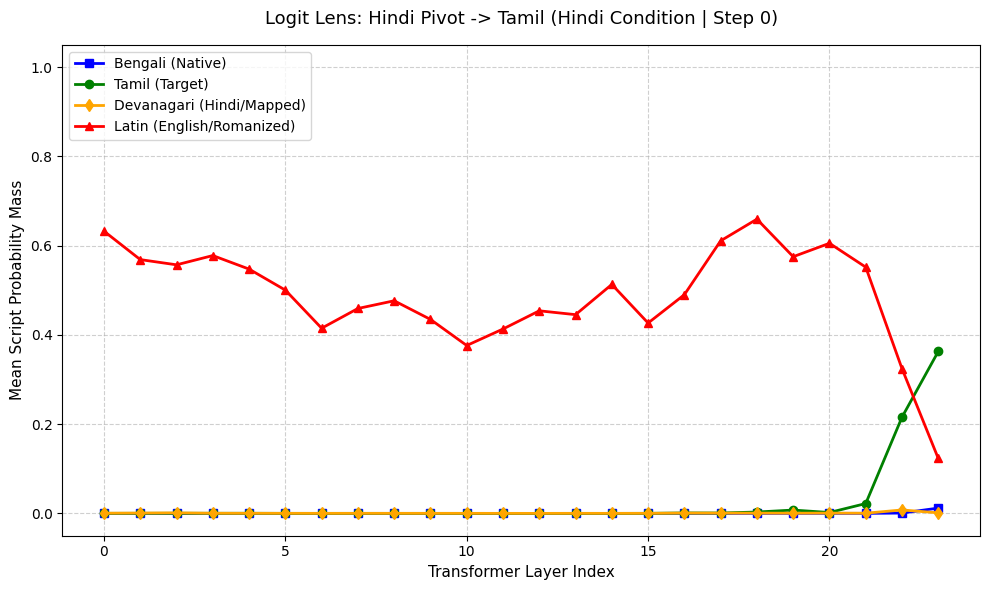

In [97]:
# 1. Native condition (Bengali to Tamil)
curve_direct = aggregate_trace_view(traces_df, condition="direct", view="last")
plot_script_curves(curve_direct, "Logit Lens: Bengali -> Tamil (Direct Condition | Step N)")

# 2. English Pivot condition (Latin to Tamil)
curve_english = aggregate_trace_view(traces_df, condition="english_pivot", view="last")
plot_script_curves(curve_english, "Logit Lens: English Pivot -> Tamil (English Condition | Step N)")

# 3. Hindi Pivot condition (Devanagari to Tamil)
curve_hindi = aggregate_trace_view(traces_df, condition="hindi_pivot", view="last")
plot_script_curves(curve_hindi, "Logit Lens: Hindi Pivot -> Tamil (Hindi Condition | Step N)")